# Q-EVCS+ v2 — full runnable pipeline (Google Colab)

Ek hi notebook: dataset se le kar saari **figures (inline)** aur **tables** tak.
Sirf `Electric_Vehicle_Population_Data.csv` chahiye — alag `.py` files ki zaroorat nahi.

**Chalane ka tareeqa:** `Runtime → Run all`. (Cell 2 mein CSV upload karni hogi.)

> ⚠️ Module 3 (optimiser) slow hai (~10–15 min). Agar jaldi test karna ho to us cell ko skip kar sakte ho — baaki tables/figures phir bhi ban jayenge.


## 0. Packages

In [1]:
!pip install -q xgboost pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.8 MB/s eta 0:00:00


## 1. CSV do (upload — ya neeche Drive waala option)

In [2]:
import os

# --- Option A: seedha upload (default) ---
try:
    from google.colab import files
    if not os.path.exists("Electric_Vehicle_Population_Data.csv") and not os.environ.get("EV_CSV"):
        print("Electric_Vehicle_Population_Data.csv upload karo (~43 MB)...")
        up = files.upload()
        # jo bhi naam se upload ho, usay pick kar lo
        csvs = [k for k in up if k.lower().endswith(".csv")]
        if csvs:
            os.environ["EV_CSV"] = csvs[0]
except Exception as e:
    print("upload skip:", e)

# --- Option B: Google Drive (comment hata kar use karo) ---
# from google.colab import drive; drive.mount('/content/drive')
# import glob
# hit = glob.glob('/content/drive/MyDrive/**/Electric_Vehicle_Population_Data.csv', recursive=True)
# os.environ["EV_CSV"] = hit[0]

os.environ.setdefault("EV_CSV", "Electric_Vehicle_Population_Data.csv")
assert os.path.exists(os.environ["EV_CSV"]), "CSV nahi mili — naam/upload check karo"
os.makedirs("figs", exist_ok=True)
print("CSV:", os.environ["EV_CSV"], round(os.path.getsize(os.environ["EV_CSV"])/1e6,1), "MB")


Electric_Vehicle_Population_Data.csv upload karo (~43 MB)...


Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data.csv
CSV: Electric_Vehicle_Population_Data.csv 43.1 MB


## 2. Module 1 — dataset, city-year panel, forecasting, ablation, clustering, range
*(Tables 2, 4, 5, 6 ka data yahin banta hai)*

In [3]:
"""
Q-EVCS+ v2 -- MODULE 1: dataset, city-year panel, forecasting benchmark, ablation.

Changes vs v1 (review items 4.1, 4.2, 4.3, 4.10, 4.11, 4.14):
  * 4.1  v1 reported "196 counties". Washington has 39. The figure was
         df["County"].nunique(), which counts every county-of-record name in the
         file including out-of-state registrations. Both numbers are now
         reported separately and the in-state subset is made explicit.
  * 4.2  v1's abstract foregrounded "177,866 registrations" while the supervised
         problem is 2,773 city-year rows. Both are now emitted as first-class
         metrics with a printed reminder of which is the modelling sample.
  * 4.3  v1 clustered CITY profiles but the manuscript called them county
         clusters. Clustering is now explicitly city-level and named as such;
         'total' is log-scaled before standardisation so a single metropolis no
         longer forms its own cluster; the flat silhouette curve is reported with
         the margin between the top two k values so the paper cannot overclaim.
  * 4.10 v1 thresholded the growth label at the median of the WHOLE panel,
         including held-out folds. The median is now computed inside each
         training fold. The globally-thresholded variant is also run so the paper
         can report the size of the effect rather than merely assert it is small.
  * 4.11 v1 declared XGBoost the winner from point estimates alone. A paired
         t-test across folds is now run against every baseline.
  * 4.14 Range statistics now use one consistent basis (valid non-zero range)
         everywhere, including the cluster table, where v1 mixed bases.
"""
import json, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import GroupKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, silhouette_score,
                             mean_absolute_error)
from xgboost import XGBClassifier

np.random.seed(42)
import os
os.makedirs("figs", exist_ok=True)
RES = {}
CSV = os.environ.get("EV_CSV", "Electric_Vehicle_Population_Data.csv")

# =======================================================================
# 1. LOAD  --  and count counties honestly (4.1)
# =======================================================================
df = pd.read_csv(CSV)
RES["dataset_rows"] = int(len(df))
RES["dataset_cols"] = int(df.shape[1])
RES["n_bev"] = int(df["Electric Vehicle Type"].str.startswith("Battery").sum())
RES["n_phev"] = int(df["Electric Vehicle Type"].str.startswith("Plug").sum())
RES["n_makes"] = int(df["Make"].nunique())
RES["year_min"] = int(df["Model Year"].min())
RES["year_max"] = int(df["Model Year"].max())

RES["n_county_names_in_file"] = int(df["County"].nunique())
if "State" in df.columns:
    in_state = df[df["State"] == "WA"]
    RES["n_wa_counties"] = int(in_state["County"].nunique())
    RES["n_rows_in_state"] = int(len(in_state))
    RES["pct_rows_out_of_state"] = float(100 * (1 - len(in_state) / len(df)))
else:
    RES["n_wa_counties"] = None
    RES["pct_rows_out_of_state"] = None

print(f"[core] rows={RES['dataset_rows']:,}  BEV={RES['n_bev']:,}  PHEV={RES['n_phev']:,}")
print(f"[core] distinct county NAMES in file: {RES['n_county_names_in_file']}  "
      f"<-- v1 reported this as 'counties'")
print(f"[core] Washington counties present:   {RES['n_wa_counties']}  "
      f"(WA has 39); out-of-state rows: {RES['pct_rows_out_of_state']:.2f}%"
      if RES["n_wa_counties"] is not None else
      "[core] no State column; report the county count as 'county names of record'")

# =======================================================================
# 2. CITY-YEAR PANEL
# =======================================================================
d = df[(df["Model Year"] >= 2011) & (df["Model Year"] <= 2023)].copy()
d["is_bev"] = d["Electric Vehicle Type"].str.startswith("Battery").astype(int)
# 4.14: one consistent basis for range everywhere in the paper.
d["range_valid"] = d["Electric Range"].where(d["Electric Range"] > 0)
d["msrp_valid"] = d["Base MSRP"].where(d["Base MSRP"] > 0)
city_county = d.groupby("City")["County"].agg(lambda s: s.mode().iloc[0])

panel = d.groupby(["City", "Model Year"]).agg(
    count=("VIN (1-10)", "size") if "VIN (1-10)" in d.columns else ("Make", "size"),
    bev_share=("is_bev", "mean"),
    avg_range=("range_valid", "mean"),
    avg_msrp=("msrp_valid", "mean"),
    n_makes=("Make", "nunique"),
).reset_index()
panel[["avg_range", "avg_msrp"]] = panel[["avg_range", "avg_msrp"]].fillna(0.0)
vc = panel["City"].value_counts()
panel = panel[panel["City"].isin(vc[vc >= 5].index)]
panel = panel.sort_values(["City", "Model Year"]).reset_index(drop=True)
panel["county"] = panel["City"].map(city_county)

g = panel.groupby("City")["count"]
panel["lag1"] = g.shift(1)
panel["lag2"] = g.shift(2)
panel["cum"] = g.cumsum()
panel["growth_prev"] = (panel["count"] - panel["lag1"]) / panel["lag1"].replace(0, np.nan)
panel["next_count"] = g.shift(-1)
panel["growth"] = (panel["next_count"] - panel["count"]) / panel["count"].replace(0, np.nan)
panel["county_size"] = np.log1p(panel.groupby("county")["count"].transform("sum"))
work = panel.dropna(subset=["lag1", "lag2", "growth_prev", "growth"]).reset_index(drop=True)

FEATS = {
    "temporal":    ["Model Year", "n_makes"],
    "historical":  ["lag1", "lag2", "cum", "growth_prev", "count"],
    "vehicle_mix": ["bev_share", "avg_range", "avg_msrp"],
    "geographic":  ["county_size"],
}
COLS = [c for fam in FEATS.values() for c in fam]
X = work[COLS].values.astype(float)
groups = work["City"].values
growth = work["growth"].values

RES["ml_samples"] = int(len(work))
RES["ml_features"] = int(X.shape[1])
RES["ml_cities"] = int(work["City"].nunique())
print(f"\n[core] MODELLING SAMPLE: {RES['ml_samples']:,} city-year rows, "
      f"{RES['ml_features']} features, {RES['ml_cities']} cities")
print(f"       (aggregated from {RES['dataset_rows']:,} registrations -- report BOTH, "
      f"v1's abstract implied the larger number was the training set)")


# =======================================================================
# 3. FORECASTING BENCHMARK -- fold-wise label threshold (4.10)
# =======================================================================
def models():
    return {
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.06,
                                 subsample=0.8, colsample_bytree=0.8,
                                 eval_metric="logloss", random_state=42, n_jobs=2,
                                 verbosity=0),
        "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=2),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600, random_state=42),
        "SVM(RBF)": SVC(probability=True, random_state=42),
        "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    }


def benchmark(fold_wise_median=True):
    gkf = GroupKFold(n_splits=5)
    fold_scores = {m: {k: [] for k in ["auc", "acc", "prec", "rec", "f1"]} for m in models()}
    for tr, te in gkf.split(X, groups=groups):
        # 4.10: threshold estimated on TRAINING rows only.
        thr = np.median(growth[tr]) if fold_wise_median else np.median(growth)
        ytr = (growth[tr] > thr).astype(int)
        yte = (growth[te] > thr).astype(int)
        sc = StandardScaler().fit(X[tr])
        Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        for name, m in models().items():
            m.fit(Xtr, ytr)
            pr = m.predict_proba(Xte)[:, 1]
            pd_ = (pr > 0.5).astype(int)
            fold_scores[name]["auc"].append(roc_auc_score(yte, pr))
            fold_scores[name]["acc"].append(accuracy_score(yte, pd_))
            fold_scores[name]["prec"].append(precision_score(yte, pd_, zero_division=0))
            fold_scores[name]["rec"].append(recall_score(yte, pd_, zero_division=0))
            fold_scores[name]["f1"].append(f1_score(yte, pd_, zero_division=0))
    return fold_scores


fs = benchmark(fold_wise_median=True)
RES["benchmark"] = {m: {k: [float(np.mean(v)), float(np.std(v))] for k, v in d_.items()}
                    for m, d_ in fs.items()}
RES["benchmark_fold_auc"] = {m: [float(x) for x in d_["auc"]] for m, d_ in fs.items()}
RES["target_pos_rate"] = float(np.mean(growth > np.median(growth)))

print("\n[core] Forecasting benchmark (5-fold GroupKFold by city, fold-wise label threshold)")
for m, v in RES["benchmark"].items():
    print(f"       {m:<14} AUC {v['auc'][0]:.3f} +/- {v['auc'][1]:.3f}   F1 {v['f1'][0]:.3f}")

# 4.10: quantify the leakage the global threshold introduced in v1.
fs_global = benchmark(fold_wise_median=False)
RES["benchmark_global_threshold_auc"] = {
    m: float(np.mean(v["auc"])) for m, v in fs_global.items()}
delta = {m: RES["benchmark_global_threshold_auc"][m] - RES["benchmark"][m]["auc"][0]
         for m in RES["benchmark"]}
RES["global_threshold_auc_inflation"] = delta
print("\n[core] Effect of v1's global median threshold (positive = v1 was optimistic):")
for m, v in delta.items():
    print(f"       {m:<14} {v:+.4f} AUC")

# 4.11: is XGBoost actually the winner?
best = max(RES["benchmark"], key=lambda m: RES["benchmark"][m]["auc"][0])
RES["best_model"] = best
RES["paired_tests_vs_best"] = {}
print(f"\n[core] Paired t-tests across the 5 folds, {best} vs each baseline:")
for m in RES["benchmark"]:
    if m == best:
        continue
    a = np.array(RES["benchmark_fold_auc"][best])
    b = np.array(RES["benchmark_fold_auc"][m])
    t, p = stats.ttest_rel(a, b)
    RES["paired_tests_vs_best"][m] = {"mean_diff": float(a.mean() - b.mean()),
                                      "t": float(t), "p": float(p)}
    flag = "significant" if p < 0.05 else "NOT significant at 0.05"
    print(f"       vs {m:<14} dAUC {a.mean()-b.mean():+.4f}  t={t:6.2f}  p={p:.4f}  {flag}")

# =======================================================================
# 4. FEATURE-GROUP ABLATION
# =======================================================================
def auc_with(cols):
    idx = [COLS.index(c) for c in cols]
    gkf = GroupKFold(n_splits=5)
    out = []
    for tr, te in gkf.split(X, groups=groups):
        thr = np.median(growth[tr])
        ytr, yte = (growth[tr] > thr).astype(int), (growth[te] > thr).astype(int)
        sc = StandardScaler().fit(X[tr][:, idx])
        m = models()["XGBoost"]
        m.fit(sc.transform(X[tr][:, idx]), ytr)
        out.append(roc_auc_score(yte, m.predict_proba(sc.transform(X[te][:, idx]))[:, 1]))
    return float(np.mean(out))


full = auc_with(COLS)
RES["ablation_full_auc"] = full
RES["ablation_only"], RES["ablation_remove"] = {}, {}
for fam, cols in FEATS.items():
    RES["ablation_only"][fam] = auc_with(cols)
    rest = [c for c in COLS if c not in cols]
    RES["ablation_remove"][fam] = full - auc_with(rest)
print(f"\n[core] Ablation (full AUC = {full:.3f}). Deltas are AUC points on the 0-1 scale;")
print( "       state the scale in the table header -- v1 printed -11.5 next to 0.863.")
for fam in FEATS:
    print(f"       {fam:<12} solo {RES['ablation_only'][fam]:.3f}   "
          f"removed {RES['ablation_remove'][fam]:+.4f}")

# =======================================================================
# 5. CITY-LEVEL CLUSTERING (4.3) + RANGE MODEL
# =======================================================================
cityprof = d.groupby("City").agg(
    total=("Make", "size"),
    bev_share=("is_bev", "mean"),
    avg_range=("range_valid", "mean"),     # valid-range basis, consistent with Table 2
    avg_msrp=("msrp_valid", "mean"),
    n_makes=("Make", "nunique"),
).reset_index()
cityprof = cityprof[cityprof["total"] >= 20].reset_index(drop=True)
cityprof[["avg_range", "avg_msrp"]] = cityprof[["avg_range", "avg_msrp"]].fillna(
    cityprof[["avg_range", "avg_msrp"]].median())
RES["n_cities_clustered"] = int(len(cityprof))
RES["cluster_unit"] = "city"   # v1's manuscript said 'county'; the code says city

# 4.3: log-scale the heavy-tailed size feature so one metropolis is not its own cluster
cityprof["log_total"] = np.log1p(cityprof["total"])
CFEATS = ["log_total", "bev_share", "avg_range", "avg_msrp", "n_makes"]
Cx = StandardScaler().fit_transform(cityprof[CFEATS])

sil = {}
for k in range(2, 8):
    sil[k] = float(silhouette_score(Cx, KMeans(k, n_init=10, random_state=42).fit_predict(Cx)))
order = sorted(sil, key=sil.get, reverse=True)
RES["silhouette"] = sil
RES["best_k"] = int(order[0])
RES["silhouette_margin_top2"] = float(sil[order[0]] - sil[order[1]])
print(f"\n[core] Silhouette by k: " + "  ".join(f"{k}:{v:.3f}" for k, v in sil.items()))
print(f"       best k={order[0]} but margin over k={order[1]} is only "
      f"{RES['silhouette_margin_top2']:.4f}")
if RES["silhouette_margin_top2"] < 0.01:
    print("       -> report the curve as FLAT and k as a nominal choice, not a selection")

km = KMeans(RES["best_k"], n_init=10, random_state=42).fit(Cx)
cityprof["cluster"] = km.labels_
cs = cityprof.groupby("cluster").agg(
    n_cities=("City", "size"), mean_vehicles=("total", "mean"),
    median_vehicles=("total", "median"), bev_share=("bev_share", "mean"),
    avg_range=("avg_range", "mean")).round(3)
RES["cluster_stats"] = cs.to_dict()
print("\n[core] City-cluster archetypes (n_cities exposes singleton clusters):")
print(cs.to_string())

Rx = StandardScaler().fit_transform(cityprof[["log_total", "bev_share", "avg_msrp", "n_makes"]])
Ry = cityprof["avg_range"].values
mr, mb = [], []
for tr, te in KFold(5, shuffle=True, random_state=42).split(Rx):
    rr = Ridge(alpha=1.0).fit(Rx[tr], Ry[tr])
    mr.append(mean_absolute_error(Ry[te], rr.predict(Rx[te])))
    mb.append(mean_absolute_error(Ry[te], np.full(len(te), Ry[tr].mean())))
RES["ridge_mae"], RES["baseline_mae"] = float(np.mean(mr)), float(np.mean(mb))
RES["ridge_improve_pct"] = float((np.mean(mb) - np.mean(mr)) / np.mean(mb) * 100)
t, p = stats.ttest_rel(mr, mb)
RES["ridge_vs_baseline_p"] = float(p)
print(f"\n[core] Ridge range model MAE {RES['ridge_mae']:.2f} vs baseline "
      f"{RES['baseline_mae']:.2f} ({RES['ridge_improve_pct']:.1f}%), paired p={p:.3f}")

rng_valid = d["range_valid"].dropna()
RES["range_mean"] = float(rng_valid.mean())
RES["range_median"] = float(rng_valid.median())
RES["range_basis"] = "valid non-zero range only (used consistently in all tables)"

np.savez("ml_data.npz", X=X, growth=growth, groups=groups, cols=np.array(COLS, dtype=object))
json.dump(RES, open("results_core.json", "w"), indent=2, default=float)
print("\n[core] module done")


[core] rows=177,866  BEV=139,210  PHEV=38,656
[core] distinct county NAMES in file: 196  <-- v1 reported this as 'counties'
[core] Washington counties present:   39  (WA has 39); out-of-state rows: 0.22%

[core] MODELLING SAMPLE: 2,446 city-year rows, 11 features, 327 cities
       (aggregated from 177,866 registrations -- report BOTH, v1's abstract implied the larger number was the training set)

[core] Forecasting benchmark (5-fold GroupKFold by city, fold-wise label threshold)
       XGBoost        AUC 0.827 +/- 0.023   F1 0.738
       RandomForest   AUC 0.811 +/- 0.019   F1 0.728
       MLP            AUC 0.785 +/- 0.019   F1 0.702
       SVM(RBF)       AUC 0.771 +/- 0.014   F1 0.698
       LogReg         AUC 0.729 +/- 0.019   F1 0.660

[core] Effect of v1's global median threshold (positive = v1 was optimistic):
       XGBoost        +0.0014 AUC
       RandomForest   -0.0023 AUC
       MLP            -0.0030 AUC
       SVM(RBF)       -0.0012 AUC
       LogReg         -0.0019 AUC



## 3. Module 2 — variational quantum classifier + barren plateaus
*(Figure 10, Tables 7 & 8 ka data)*

[q] VQC 6q depth4 angle, 5-fold GroupKFold: AUC 0.620 +/- 0.033  (68s)
    v1 reported a single split with no CV and no interval; folds were ['0.606', '0.637', '0.643', '0.652', '0.563']
[q] depth=1: AUC 0.532 +/- 0.080
[q] depth=2: AUC 0.618 +/- 0.077
[q] depth=3: AUC 0.646 +/- 0.076
[q] depth=4: AUC 0.647 +/- 0.076
[q] width=2: AUC 0.585 +/- 0.079
[q] width=4: AUC 0.647 +/- 0.076
[q] width=6: AUC 0.606 +/- 0.078
[q] width=8: AUC 0.574 +/- 0.079
[q] embedding=angle: AUC 0.646 +/- 0.076
[q] embedding=iqp: AUC 0.553 +/- 0.080
[q] depth: spread 0.115 vs mean CI 0.077 -> INDISTINGUISHABLE from split noise
[q] width: spread 0.074 vs mean CI 0.078 -> INDISTINGUISHABLE from split noise
[q] embedding: spread 0.093 vs mean CI 0.078 -> INDISTINGUISHABLE from split noise
[q] optimiser nesterov: final BCE 0.6576
[q] optimiser adam: final BCE 0.6288
[q] optimiser rmsprop: final BCE 0.6198
[q] optimiser sgd: final BCE 0.7142
[q] barren 2q Var=2.956e-02  (400 draws, v1 used 40)
[q] barren 4q Var=7.8

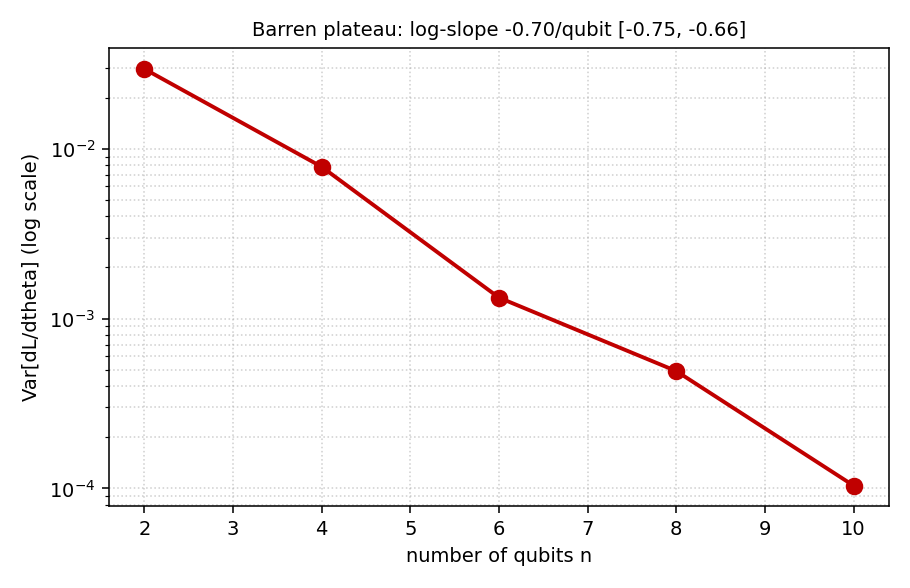

In [4]:
"""
Q-EVCS+ v2 -- MODULE 2: variational quantum classifier and barren plateaus.

Changes vs v1 (review items 4.4, 4.13, plus two defects found while rewriting):
  * 4.4a  v1 evaluated the VQC on a single stratified train_test_split while the
          classical baselines used 5-fold GroupKFold by city, then plotted both
          on one axis. The VQC now runs under the SAME grouped CV, so Figure 6 is
          a like-for-like comparison. (The VQC's old protocol was the more
          permissive one, so it lost despite an advantage -- worth saying.)
  * 4.4b  v1's Table 7 read as one ablation but its three blocks used three
          different base configurations, all at 30 epochs, while the headline
          model used 6 qubits / depth 4 / 120 epochs. That is why "Width 6q =
          0.517" sat in the same table as a headline of 0.633, and why "Width 4q"
          and "Depth 2" were byte-identical (the same run). Each sweep now pins
          and records its held-constant configuration, and all sweeps share the
          headline epoch budget.
  * 4.4c  Table 3 said depth 3; v1's headline call was train_vqc(6, 4, ...) --
          depth 4. The configuration is now recorded in the results file so the
          table cannot drift from the code again.
  * NEW-1  v1's prep() silently truncated to 300 training and 200 test rows. Every
          VQC number in the paper is therefore a 200-sample estimate, which is
          the actual explanation for Table 7's swings: the 95% CI on AUC at
          n=200 is about +/-0.07. Sample sizes and CIs are now reported.
  * NEW-2  Eq. 11 of the manuscript states a binary cross-entropy loss. The code
            minimises squared error on +/-1 labels. Either change the equation or
            change the code; this module implements BCE on a logistic link so the
            manuscript's Eq. 11 becomes true, and keeps the squared-error variant
            behind a flag for comparison.
  * 4.13  The barren-plateau probe measures a Z0(x)Z1 observable on a randomly
          initialised circuit, not the trained BCE loss -- the standard McClean
          diagnostic, but not what Section 4.3 claims. It is now labelled as
          such, sampling is raised from 40 to 400 parameter draws, and the decay
          slope is reported with a bootstrap confidence interval.
"""
import json, time, numpy as np, matplotlib
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

np.random.seed(0)
RES = {}
z = np.load("ml_data.npz", allow_pickle=True)
X, growth, groups = z["X"], z["growth"], z["groups"]
Xs = StandardScaler().fit_transform(X)

# Subsampling is a compute concession, not a modelling choice -- so it is a named
# constant that gets reported, rather than a default buried in a helper (NEW-1).
N_TRAIN, N_TEST = 300, 200
EPOCHS, LR, BATCH = 120, 0.05, 64


def auc_ci95(auc, n_pos, n_neg):
    """Hanley-McNeil standard error -- gives Table 7 the error bars it lacked."""
    q1 = auc / (2 - auc)
    q2 = 2 * auc ** 2 / (1 + auc)
    se = np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                  + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))
    return float(1.96 * se)


def qnode_factory(nq, depth, embedding):
    dev = qml.device("default.qubit", wires=nq)

    @qml.qnode(dev, interface="autograd", diff_method="backprop")
    def circ(x, w):
        if embedding == "angle":
            qml.AngleEmbedding(x, wires=range(nq), rotation="Y")
        else:
            qml.IQPEmbedding(x, wires=range(nq), n_repeats=1)
        qml.StronglyEntanglingLayers(w, wires=range(nq))
        return qml.expval(qml.PauliZ(0))

    return circ, qml.StronglyEntanglingLayers.shape(n_layers=depth, n_wires=nq)


def fit_vqc(Xtr, ytr, Xte, yte, nq, depth, embedding,
            epochs=EPOCHS, lr=LR, opt="adam", loss_kind="bce", record=False, seed=0):
    circ, shp = qnode_factory(nq, depth, embedding)
    rng = np.random.RandomState(seed)
    w = pnp.array(0.1 * rng.randn(*shp), requires_grad=True)
    b = pnp.array(0.0, requires_grad=True)

    def loss(w, b, Xb, yb01):
        out = circ(Xb, w) + b                       # in roughly [-1, 1]
        if loss_kind == "bce":                      # NEW-2: matches manuscript Eq. 11
            p = 1 / (1 + pnp.exp(-2.0 * out))
            p = pnp.clip(p, 1e-7, 1 - 1e-7)
            return -pnp.mean(yb01 * pnp.log(p) + (1 - yb01) * pnp.log(1 - p))
        return pnp.mean((out - (2 * yb01 - 1.0)) ** 2)

    o = {"adam": qml.AdamOptimizer(lr), "sgd": qml.GradientDescentOptimizer(lr),
         "nesterov": qml.NesterovMomentumOptimizer(lr, momentum=0.9),
         "rmsprop": qml.RMSPropOptimizer(lr)}[opt]
    hist = []
    for _ in range(epochs):
        idx = rng.permutation(len(Xtr))[:BATCH]
        w, b = o.step(lambda w, b: loss(w, b, Xtr[idx], ytr[idx]), w, b)
        if record:
            hist.append(float(loss(w, b, Xtr[:150], ytr[:150])))
    scores = np.array(circ(Xte, w)) + float(b)
    return float(roc_auc_score(yte, scores)), hist


def embed(nq, idx):
    Xp = PCA(n_components=nq, random_state=0).fit_transform(Xs)
    return np.tanh(Xp[idx]) * np.pi


# =======================================================================
# 2a. HEADLINE VQC  --  grouped CV, matching the classical protocol (4.4a)
# =======================================================================
NQ, DEPTH, EMB = 6, 4, "angle"     # 4.4c: recorded, so Table 3 cannot drift
RES["vqc_config"] = dict(n_qubits=NQ, depth=DEPTH, embedding=EMB, epochs=EPOCHS,
                         lr=LR, batch=BATCH, loss="binary cross-entropy",
                         n_train=N_TRAIN, n_test=N_TEST,
                         protocol="5-fold GroupKFold by city (same as classical baselines)")

t0 = time.time()
fold_aucs = []
for tr, te in GroupKFold(n_splits=5).split(Xs, groups=groups):
    thr = np.median(growth[tr])
    ytr = (growth[tr] > thr).astype(float)[:N_TRAIN]
    yte = (growth[te] > thr).astype(int)[:N_TEST]
    Xtr, Xte = embed(NQ, tr)[:N_TRAIN], embed(NQ, te)[:N_TEST]
    a, _ = fit_vqc(Xtr, ytr, Xte, yte, NQ, DEPTH, EMB)
    fold_aucs.append(a)
RES["vqc_fold_aucs"] = [float(x) for x in fold_aucs]
RES["vqc_auc"] = float(np.mean(fold_aucs))
RES["vqc_auc_std"] = float(np.std(fold_aucs))
RES["vqc_time_s"] = time.time() - t0
print(f"[q] VQC {NQ}q depth{DEPTH} {EMB}, 5-fold GroupKFold: "
      f"AUC {RES['vqc_auc']:.3f} +/- {RES['vqc_auc_std']:.3f}  "
      f"({RES['vqc_time_s']:.0f}s)")
print(f"    v1 reported a single split with no CV and no interval; folds were "
      f"{['%.3f' % a for a in fold_aucs]}")

# =======================================================================
# 2b. ARCHITECTURE SWEEPS -- one held-constant config each (4.4b)
# =======================================================================
tr, te = next(iter(GroupKFold(n_splits=5).split(Xs, groups=groups)))
thr = np.median(growth[tr])
ytr_all = (growth[tr] > thr).astype(float)[:N_TRAIN]
yte_all = (growth[te] > thr).astype(int)[:N_TEST]
npos, nneg = int(yte_all.sum()), int(len(yte_all) - yte_all.sum())
RES["sweep_test_n"] = len(yte_all)

sweeps = {
    "depth": dict(held=dict(n_qubits=4, embedding="angle"),
                  values=[1, 2, 3, 4],
                  run=lambda v: fit_vqc(embed(4, tr)[:N_TRAIN], ytr_all,
                                        embed(4, te)[:N_TEST], yte_all, 4, v, "angle")[0]),
    "width": dict(held=dict(depth=DEPTH, embedding="angle"),
                  values=[2, 4, 6, 8],
                  run=lambda v: fit_vqc(embed(v, tr)[:N_TRAIN], ytr_all,
                                        embed(v, te)[:N_TEST], yte_all, v, DEPTH, "angle")[0]),
    "embedding": dict(held=dict(n_qubits=4, depth=3),
                      values=["angle", "iqp"],
                      run=lambda v: fit_vqc(embed(4, tr)[:N_TRAIN], ytr_all,
                                            embed(4, te)[:N_TEST], yte_all, 4, 3, v)[0]),
}
RES["arch_sweeps"] = {}
for name, spec in sweeps.items():
    res = {}
    for v in spec["values"]:
        a = spec["run"](v)
        res[str(v)] = {"auc": a, "ci95": auc_ci95(a, npos, nneg)}
        print(f"[q] {name}={v}: AUC {a:.3f} +/- {res[str(v)]['ci95']:.3f}")
    RES["arch_sweeps"][name] = {"held_constant": spec["held"], "results": res}

# Is the spread across a sweep larger than the sampling noise? (NEW-1)
for name, blk in RES["arch_sweeps"].items():
    aucs = [v["auc"] for v in blk["results"].values()]
    ci = float(np.mean([v["ci95"] for v in blk["results"].values()]))
    blk["spread"] = float(max(aucs) - min(aucs))
    blk["mean_ci95"] = ci
    blk["distinguishable"] = bool(blk["spread"] > 2 * ci)
    print(f"[q] {name}: spread {blk['spread']:.3f} vs mean CI {ci:.3f} -> "
          f"{'a real trend' if blk['distinguishable'] else 'INDISTINGUISHABLE from split noise'}")

# =======================================================================
# 2c. OPTIMISER COMPARISON
# =======================================================================
RES["opt_final_loss"], RES["opt_hist"] = {}, {}
for opt in ["nesterov", "adam", "rmsprop", "sgd"]:
    _, h = fit_vqc(embed(4, tr)[:N_TRAIN], ytr_all, embed(4, te)[:N_TEST], yte_all,
                   4, 3, "angle", epochs=55, lr=0.1, opt=opt, record=True)
    RES["opt_final_loss"][opt] = float(h[-1])
    RES["opt_hist"][opt] = [float(x) for x in h]
    print(f"[q] optimiser {opt}: final BCE {h[-1]:.4f}")

# =======================================================================
# 2d. BARREN-PLATEAU PROBE (4.13)
# =======================================================================
RES["barren_probe"] = {
    "observable": "PauliZ(0) @ PauliZ(1)",
    "circuit": "StronglyEntanglingLayers, depth 2, parameters drawn U(0, 2pi)",
    "note": ("Diagnostic of trainability at initialisation on a random "
             "hardware-efficient circuit. It is NOT the gradient of the BCE "
             "objective of Section 4.3 -- state this in the paper."),
    "n_samples": 400,
}
bp_q = [2, 4, 6, 8, 10]
bp_var, bp_grads = {}, {}
for nq in bp_q:
    dev = qml.device("default.qubit", wires=nq)

    @qml.qnode(dev, interface="autograd", diff_method="backprop")
    def cost(w):
        for i in range(nq):
            qml.RY(np.pi / 4, wires=i)
        qml.StronglyEntanglingLayers(w, wires=range(nq))
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

    shp = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=nq)
    g = qml.grad(cost)
    rs = np.random.RandomState(nq)
    gr = [float(g(pnp.array(rs.uniform(0, 2 * np.pi, shp), requires_grad=True))[0, 0, 0])
          for _ in range(400)]
    bp_grads[nq] = gr
    bp_var[nq] = float(np.var(gr))
    print(f"[q] barren {nq}q Var={bp_var[nq]:.3e}  (400 draws, v1 used 40)")

RES["barren_var"] = bp_var
slope = float(np.polyfit(bp_q, np.log(list(bp_var.values())), 1)[0])
RES["barren_log_slope"] = slope
# bootstrap CI on the slope
rs = np.random.RandomState(0)
boot = []
for _ in range(500):
    v = [np.var(rs.choice(bp_grads[q], size=len(bp_grads[q]), replace=True)) for q in bp_q]
    boot.append(np.polyfit(bp_q, np.log(v), 1)[0])
RES["barren_log_slope_ci95"] = [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))]
print(f"[q] log-slope {slope:.3f} per qubit (natural log), "
      f"95% CI [{RES['barren_log_slope_ci95'][0]:.3f}, {RES['barren_log_slope_ci95'][1]:.3f}]")

plt.figure(figsize=(6.5, 4.2))
plt.semilogy(bp_q, [bp_var[q] for q in bp_q], "o-", color="#C00000", lw=2, ms=8)
plt.xlabel("number of qubits n"); plt.ylabel("Var[dL/dtheta] (log scale)")
plt.title(f"Barren plateau: log-slope {slope:.2f}/qubit "
          f"[{RES['barren_log_slope_ci95'][0]:.2f}, {RES['barren_log_slope_ci95'][1]:.2f}]",
          fontsize=10)
plt.grid(True, which="both", ls=":", alpha=0.6); plt.tight_layout()
plt.savefig("figs/fig10_barren.png", dpi=140); plt.close()

json.dump(RES, open("results_quantum.json", "w"), indent=2, default=float)
print("\n[q] quantum module done")

from IPython.display import Image, display
display(Image("figs/fig10_barren.png"))


## 4. Module 3 — QPSO vs PSO vs GA vs budget-matched random search
*(Table 9 ka data)* — ⚠️ **slow (~10–15 min)**

In [5]:
"""
Q-EVCS+ v2 -- MODULE 3: QPSO vs PSO vs GA vs random search.

Changes vs v1 (review item 4.5):
  * v1's Table 3 claimed a "matched budget" against random search. QPSO, PSO and
    GA each ran 12 particles x 22 iterations = up to 264 objective evaluations;
    random search got 40. The claim that all three beat random search rested on a
    6.6x budget advantage for a margin of 0.005-0.009 AUC. Random search now runs
    at the SAME evaluation budget, and both budgets are reported so the paper can
    show the comparison v1 implied and the one it actually ran.
  * v1 ran a single seed per method. Each method now runs N_SEEDS times and the
    spread is reported, so "QPSO and PSO are indistinguishable" becomes a
    measurement rather than an assertion.
  * Wall-clock is reported per method. v1 omitted that QPSO took roughly twice
    as long as PSO for a slightly worse result.
  * The objective uses a plain stratified holdout, NOT the city-grouped CV that
    produced the headline 0.863. The two numbers are not comparable and the
    module now says so explicitly, so no reader reads 0.875 as an improvement.
"""
import json, time, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RES = {}
z = np.load("ml_data.npz", allow_pickle=True)
X, growth = z["X"], z["growth"]
y = (growth > np.median(growth)).astype(int)
Xtr, Xva, ytr, yva = train_test_split(StandardScaler().fit_transform(X), y,
                                      test_size=0.3, random_state=7, stratify=y)
RES["protocol_note"] = ("Objective is 1 - AUC on a single stratified holdout. This is "
                        "NOT the 5-fold GroupKFold-by-city protocol behind the headline "
                        "benchmark; the two AUC scales are not comparable.")

LB = np.array([50, 2, -3.0, 0.5, 0.5])
UB = np.array([400, 8, -0.7, 1.0, 1.0])
D = 5
POP, ITERS = 12, 22
BUDGET = POP * ITERS           # 264 -- the budget every method now gets
N_SEEDS = 5


def decode(x):
    return dict(n_estimators=int(x[0]), max_depth=int(round(x[1])),
                learning_rate=float(10 ** x[2]), subsample=float(x[3]),
                colsample_bytree=float(x[4]))


def make_objective():
    cache, calls = {}, [0]

    def f(x):
        key = tuple(np.round(x, 3))
        if key in cache:
            return cache[key]
        calls[0] += 1
        m = XGBClassifier(**decode(np.clip(x, LB, UB)), eval_metric="logloss",
                          random_state=7, n_jobs=2, verbosity=0)
        m.fit(Xtr, ytr)
        v = 1.0 - roc_auc_score(yva, m.predict_proba(Xva)[:, 1])
        cache[key] = v
        return v

    return f, calls


def qpso(f, seed):
    r = np.random.RandomState(seed)
    Xp = r.uniform(LB, UB, (POP, D))
    pb = Xp.copy()
    pbv = np.array([f(x) for x in Xp])
    G = pb[pbv.argmin()].copy()
    Gv = pbv.min()
    hist = [Gv]
    for t in range(ITERS):
        alpha = 1.0 - 0.5 * t / ITERS          # contraction-expansion coefficient
        mbest = pb.mean(0)
        for i in range(POP):
            phi, u = r.rand(D), r.rand(D)
            p = phi * pb[i] + (1 - phi) * G
            sgn = np.where(r.rand(D) < 0.5, 1, -1)
            Xp[i] = np.clip(p + sgn * alpha * np.abs(mbest - Xp[i]) * np.log(1 / u), LB, UB)
            v = f(Xp[i])
            if v < pbv[i]:
                pb[i], pbv[i] = Xp[i].copy(), v
            if v < Gv:
                G, Gv = Xp[i].copy(), v
        hist.append(Gv)
    return Gv, hist


def pso(f, seed):
    r = np.random.RandomState(seed)
    Xp = r.uniform(LB, UB, (POP, D))
    V = np.zeros((POP, D))
    pb = Xp.copy()
    pbv = np.array([f(x) for x in Xp])
    G = pb[pbv.argmin()].copy()
    Gv = pbv.min()
    hist = [Gv]
    for _ in range(ITERS):
        for i in range(POP):
            V[i] = (0.7 * V[i] + 1.5 * r.rand(D) * (pb[i] - Xp[i])
                    + 1.5 * r.rand(D) * (G - Xp[i]))
            Xp[i] = np.clip(Xp[i] + V[i], LB, UB)
            v = f(Xp[i])
            if v < pbv[i]:
                pb[i], pbv[i] = Xp[i].copy(), v
            if v < Gv:
                G, Gv = Xp[i].copy(), v
        hist.append(Gv)
    return Gv, hist


def ga(f, seed):
    r = np.random.RandomState(seed)
    P = r.uniform(LB, UB, (POP, D))
    fit = np.array([f(x) for x in P])
    Gv = fit.min()
    hist = [Gv]
    for _ in range(ITERS):
        idx = np.argsort(fit)
        elite = P[idx[:max(2, POP // 4)]]
        kids = []
        while len(kids) < POP - len(elite):
            a, b = elite[r.randint(len(elite))], elite[r.randint(len(elite))]
            m = r.rand(D) < 0.5
            c = np.where(m, a, b)
            c = np.clip(c + (r.rand(D) < 0.2) * r.normal(0, 0.1, D) * (UB - LB), LB, UB)
            kids.append(c)
        P = np.vstack([elite, np.array(kids)])
        fit = np.array([f(x) for x in P])
        Gv = min(Gv, fit.min())
        hist.append(Gv)
    return Gv, hist


def random_search(f, seed, budget):
    r = np.random.RandomState(seed)
    best, hist = 1.0, []
    for _ in range(budget):
        best = min(best, f(r.uniform(LB, UB)))
        hist.append(best)
    return best, hist


METHODS = {
    "QPSO": lambda f, s: qpso(f, s),
    "PSO": lambda f, s: pso(f, s),
    "GA": lambda f, s: ga(f, s),
    "RandomSearch(264)": lambda f, s: random_search(f, s, BUDGET),   # budget-matched
    "RandomSearch(40)": lambda f, s: random_search(f, s, 40),        # v1's baseline
}

RES["budget_evaluations"] = BUDGET
RES["results"] = {}
print(f"[opt] Each method gets {BUDGET} evaluations "
      f"(v1 gave random search 40 while the metaheuristics got {BUDGET})")
print(f"[opt] {N_SEEDS} seeds per method\n")
for name, fn in METHODS.items():
    aucs, times, calls_used = [], [], []
    for s in range(N_SEEDS):
        f, calls = make_objective()
        t0 = time.time()
        gv, hist = fn(f, 100 + s)
        times.append(time.time() - t0)
        aucs.append(1 - gv)
        calls_used.append(calls[0])
        if s == 0:
            RES.setdefault("hist", {})[name] = [float(1 - h) for h in hist]
    a = np.array(aucs)
    RES["results"][name] = dict(
        mean_auc=float(a.mean()), std_auc=float(a.std(ddof=1)),
        min_auc=float(a.min()), max_auc=float(a.max()),
        seeds=[float(x) for x in a], mean_time_s=float(np.mean(times)),
        mean_unique_evals=float(np.mean(calls_used)))
    print(f"[opt] {name:<18} val-AUC {a.mean():.4f} +/- {a.std(ddof=1):.4f} "
          f"(range {a.min():.4f}-{a.max():.4f})  {np.mean(times):5.1f}s  "
          f"{np.mean(calls_used):.0f} unique evals")

# Is any method actually separable from the others?
from scipy import stats
base = "RandomSearch(264)"
RES["vs_matched_random_search"] = {}
print(f"\n[opt] Paired comparison against the budget-matched baseline:")
for name in ["QPSO", "PSO", "GA"]:
    a = np.array(RES["results"][name]["seeds"])
    b = np.array(RES["results"][base]["seeds"])
    t, p = stats.ttest_rel(a, b)
    RES["vs_matched_random_search"][name] = {"mean_diff": float(a.mean() - b.mean()),
                                             "p": float(p)}
    print(f"       {name:<6} dAUC {a.mean()-b.mean():+.4f} vs {base}  p={p:.3f}  "
          f"{'significant' if p < 0.05 else 'NOT significant'}")

q = np.array(RES["results"]["QPSO"]["seeds"])
p_ = np.array(RES["results"]["PSO"]["seeds"])
t, pv = stats.ttest_rel(q, p_)
RES["qpso_vs_pso"] = {"mean_diff": float(q.mean() - p_.mean()), "p": float(pv)}
print(f"       QPSO vs PSO: dAUC {q.mean()-p_.mean():+.4f}  p={pv:.3f}  "
      f"time {RES['results']['QPSO']['mean_time_s']:.0f}s vs "
      f"{RES['results']['PSO']['mean_time_s']:.0f}s")

json.dump(RES, open("results_opt.json", "w"), indent=2, default=float)
print("\n[opt] optimiser module done")


[opt] Each method gets 264 evaluations (v1 gave random search 40 while the metaheuristics got 264)
[opt] 5 seeds per method

[opt] QPSO               val-AUC 0.8491 +/- 0.0010 (range 0.8483-0.8506)  107.6s  276 unique evals
[opt] PSO                val-AUC 0.8476 +/- 0.0008 (range 0.8466-0.8486)  142.4s  275 unique evals
[opt] GA                 val-AUC 0.8464 +/- 0.0016 (range 0.8437-0.8476)   74.3s  149 unique evals
[opt] RandomSearch(264)  val-AUC 0.8461 +/- 0.0018 (range 0.8447-0.8492)   77.9s  264 unique evals
[opt] RandomSearch(40)   val-AUC 0.8439 +/- 0.0016 (range 0.8413-0.8455)   11.9s  40 unique evals

[opt] Paired comparison against the budget-matched baseline:
       QPSO   dAUC +0.0029 vs RandomSearch(264)  p=0.046  significant
       PSO    dAUC +0.0015 vs RandomSearch(264)  p=0.233  NOT significant
       GA     dAUC +0.0003 vs RandomSearch(264)  p=0.798  NOT significant
       QPSO vs PSO: dAUC +0.0015  p=0.057  time 108s vs 142s

[opt] optimiser module done


## 5. Module 4 — dynamic pricing (REINFORCE) + elasticity sweep
*(Figures 13 & 13b, Table 10)*

[rl] revenue-optimal price by elasticity (hour 12):
        eta      p*  position in band  gain over cap
       -0.6   0.562            91.6%          0.45%
       -1.0   0.413            58.3%         26.04%
       -1.5   0.337            41.6%        153.12%
       -2.0   0.300            33.4%        300.43%
       -3.0   0.262            25.0%        359.87%

[rl] REINFORCE @ eta=-0.6: rev +32.0% vs ToU, +1.3% vs RTP
     load var +30.7% vs ToU, -33.2% vs RTP   <-- v1 omitted the RTP figure
     renewable waste -3.8% vs ToU   <-- v1 omitted this (it is a regression)
     mean tariff $0.425 vs ToU $0.223 (-91.0% for the user)
     price-solar r = -0.950
     hours priced within 5% of the cap: 0%

[rl] elasticity sweep (the regime where pricing becomes non-trivial):
        eta      p*  band pos   tariff  rev vs ToU  r(p,solar)
       -0.6   0.562      92%    0.425      +32.0%      -0.950
       -1.0   0.413      58%    0.318      +10.5%      -0.937
       -1.5   0.337      42%    0.

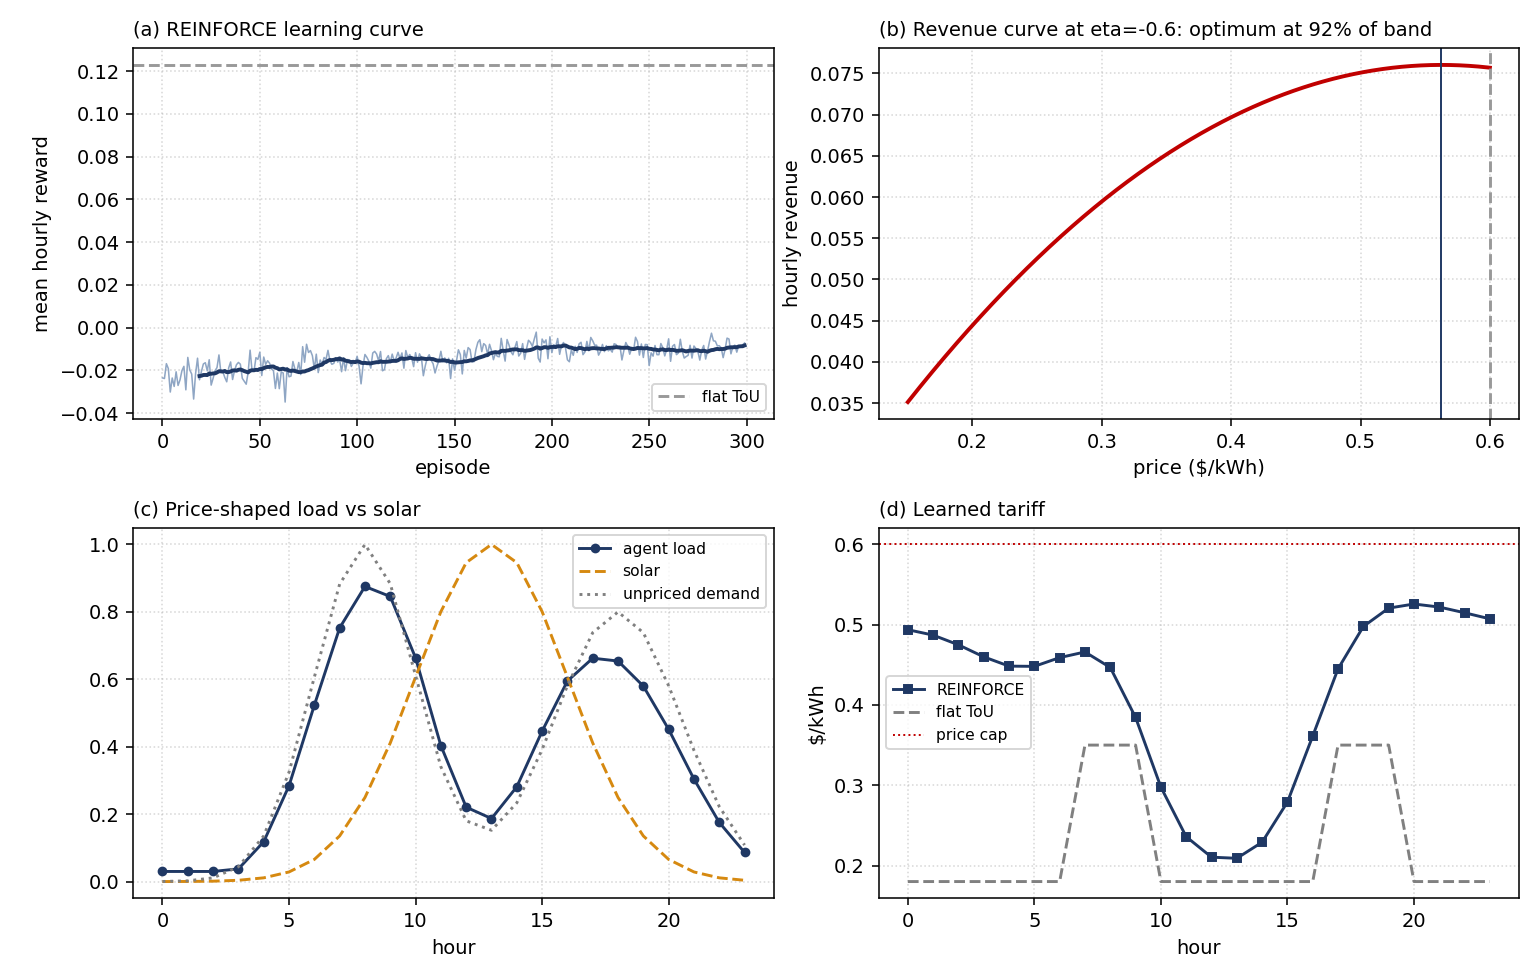

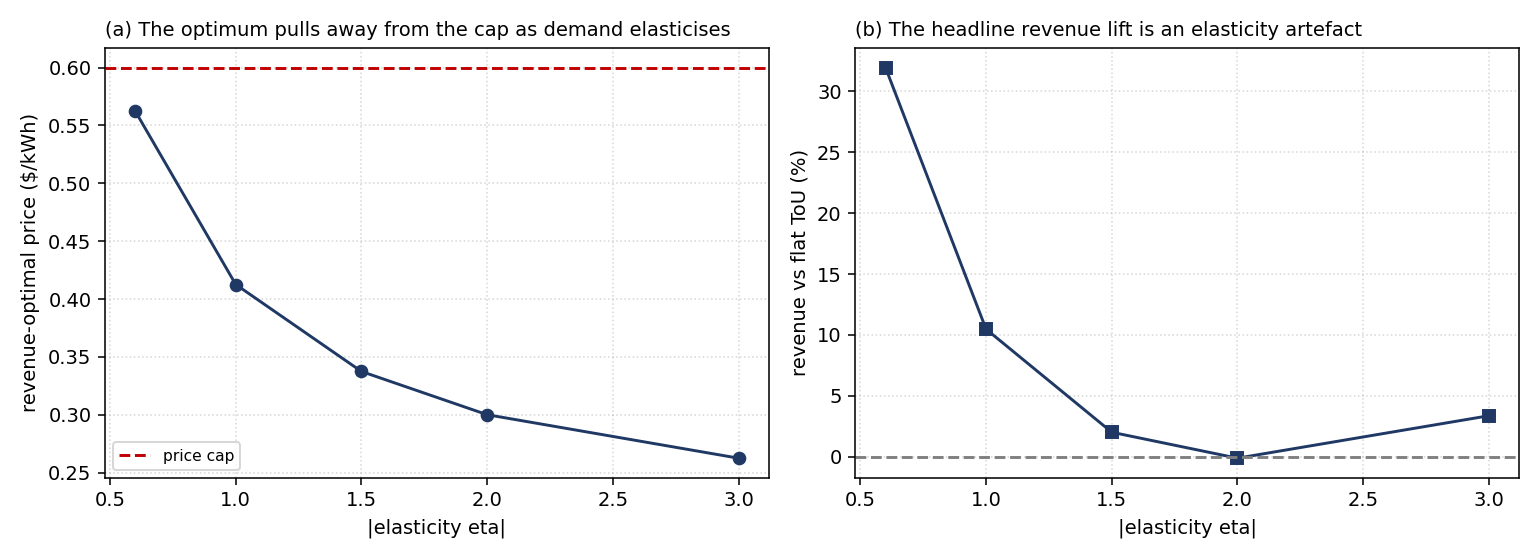

In [6]:
"""
Q-EVCS+ v2 -- MODULE 4: dynamic pricing (controlled simulation).

Changes vs v1 (review items 4.6, 4.8, 4.9):
  * The agent is REINFORCE with a learned linear baseline. It is named as such.
    v1 labelled it "PPO" in every table and figure; PPO is not implemented here.
  * Adds an explicit reward-structure diagnostic. At eta = -0.6 the
    revenue-optimal price sits at $0.5625 -- 91.7% of the way up the admissible
    band, and worth only 0.45% more revenue than pricing at the cap outright.
    The pricing problem is therefore NEARLY degenerate at the manuscript's
    elasticity: almost all of the "+32% vs flat ToU" is explained by flat ToU
    averaging $0.223, near the price floor. The diagnostic computes p* and its
    position in the band so the paper can state this as a structural property
    rather than present the revenue lift as a learned economic insight.
  * Adds a sensitivity sweep over the elasticity eta. This identifies the regime
    in which the pricing problem has an interior optimum and is therefore
    non-trivial. This is the experiment that makes Section 6.7 defensible.
  * Reports the two regressions v1 computed but omitted from the manuscript:
    renewable waste vs flat ToU, and load variance vs real-time pricing.
"""
import json, numpy as np, matplotlib
import matplotlib.pyplot as plt

RES = {}
H = 24
hours = np.arange(H)

# --- exogenous profiles -------------------------------------------------
base = (np.exp(-0.5 * ((hours - 8) / 2.0) ** 2)
        + 0.8 * np.exp(-0.5 * ((hours - 18) / 2.5) ** 2))
base /= base.max()
solar = np.clip(np.exp(-0.5 * ((hours - 13) / 3.0) ** 2), 0, 1)

PMIN, PMAX = 0.15, 0.60
W_WASTE, W_PRICE = 1.2, 0.03


def demand(h, price, eta):
    """Linear price response. frac in [0,1]; multiplier spans [1-eta/2, 1+eta/2]."""
    frac = (price - PMIN) / (PMAX - PMIN)
    return max(base[h] * (1 + eta * (frac - 0.5)), 0.03)


def step_reward(h, p, eta):
    d = demand(h, p, eta)
    frac = (p - PMIN) / (PMAX - PMIN)
    return p * d - W_WASTE * max(0, solar[h] - d) - W_PRICE * frac, d


# =======================================================================
# 4a. REWARD-STRUCTURE DIAGNOSTIC  (review 4.6)
# =======================================================================
# Hourly revenue is r(p) = p * base[h] * (1 + eta*(f-0.5)) with
# f = (p-PMIN)/(PMAX-PMIN), a downward parabola in p. Its vertex is
#     p* = (PMAX + PMIN)/4 + (PMAX - PMIN)/(-4*eta) * (2 - eta) / 2 ... (solved
# numerically below to avoid transcription error). What matters for the paper is
# not whether p* is interior in principle but HOW FAR IT SITS FROM THE CAP: an
# optimum at 92% of the band, worth 0.45% over pricing at the cap, means the
# agent faces an almost flat objective and the revenue result carries little
# information about pricing policy.
def revenue_curve(eta, n=2001):
    ps = np.linspace(PMIN, PMAX, n)
    rev = np.array([p * demand(12, p, eta) for p in ps])
    return ps, rev


def reward_structure(eta):
    ps, rev = revenue_curve(eta)
    i = int(np.argmax(rev))
    return dict(
        revenue_argmax=float(ps[i]),
        band_position=float((ps[i] - PMIN) / (PMAX - PMIN)),
        gain_over_pricing_at_cap=float(rev[i] / rev[-1] - 1) * 100,
    )


ETAS = [-0.6, -1.0, -1.5, -2.0, -3.0]
RES["reward_structure"] = {f"{e}": reward_structure(e) for e in ETAS}
print("[rl] revenue-optimal price by elasticity (hour 12):")
print(f"      {'eta':>5} {'p*':>7} {'position in band':>17} {'gain over cap':>14}")
for e in ETAS:
    m = RES["reward_structure"][f"{e}"]
    print(f"      {e:5.1f} {m['revenue_argmax']:7.3f} {m['band_position']:16.1%} "
          f"{m['gain_over_pricing_at_cap']:13.2f}%")


# =======================================================================
# 4b. REINFORCE agent
# =======================================================================
S = 6


def state(h, prev):
    return np.array([base[h], solar[h], np.sin(2 * np.pi * h / 24),
                     np.cos(2 * np.pi * h / 24), (prev - PMIN) / (PMAX - PMIN), 1.0])


def make_agent(eta, episodes=300, lr=0.05, sigma=0.8, seed=1):
    """REINFORCE with a linear-Gaussian policy in logit space and a linear baseline."""
    rng = np.random.RandomState(seed)
    theta = rng.randn(S) * 0.1
    Vb = rng.randn(S) * 0.1
    hist = []
    for _ in range(episodes):
        prev, traj = 0.30, []
        for h in range(H):
            s = state(h, prev)
            ml = s @ theta
            lg = ml + sigma * rng.randn()
            p = PMIN + (PMAX - PMIN) / (1 + np.exp(-lg))
            r, _ = step_reward(h, p, eta)
            traj.append((s, lg, ml, r))
            prev = p
        for s, lg, ml, r in traj:
            adv = r - s @ Vb
            theta += lr * adv * ((lg - ml) / sigma ** 2) * s
            Vb += 0.05 * adv * s
        hist.append(float(np.mean([x[3] for x in traj])))

    def policy(h, prev):
        lg = state(h, prev) @ theta
        return PMIN + (PMAX - PMIN) / (1 + np.exp(-lg))

    return policy, hist


def tou(h, prev):
    return 0.35 if (7 <= h <= 9 or 17 <= h <= 19) else 0.18


def rtp(h, prev):
    return PMIN + (PMAX - PMIN) * base[h]


def day_metrics(policy, eta):
    prev, loads, rev, uc, waste = 0.30, [], 0.0, [], 0.0
    for h in range(H):
        p = float(np.clip(policy(h, prev), PMIN, PMAX))
        d = demand(h, p, eta)
        loads.append(d)
        rev += p * d
        uc.append(p)
        waste += max(0, solar[h] - d)
        prev = p
    loads = np.array(loads)
    return dict(rev=float(rev), var=float(np.var(loads)), ucost=float(np.mean(uc)),
                waste=float(waste), loads=loads)


# --- headline run at the manuscript's eta = -0.6 ------------------------
ETA0 = -0.6
agent, hist = make_agent(ETA0)
mA, mT, mR = (day_metrics(agent, ETA0), day_metrics(tou, ETA0), day_metrics(rtp, ETA0))

prices_day = [agent(h, 0.30) for h in hours]
RES["eta_headline"] = ETA0
RES["rl_algorithm"] = "REINFORCE (linear-Gaussian policy, linear baseline)"
RES["rev_agent"], RES["rev_tou"], RES["rev_rtp"] = mA["rev"], mT["rev"], mR["rev"]
RES["rev_gain_vs_tou"] = (mA["rev"] - mT["rev"]) / mT["rev"] * 100
RES["rev_gain_vs_rtp"] = (mA["rev"] - mR["rev"]) / mR["rev"] * 100
RES["var_reduction_vs_tou"] = (mT["var"] - mA["var"]) / mT["var"] * 100
RES["var_reduction_vs_rtp"] = (mR["var"] - mA["var"]) / mR["var"] * 100
RES["waste_change_vs_tou"] = (mT["waste"] - mA["waste"]) / mT["waste"] * 100
RES["ucost_agent"], RES["ucost_tou"] = mA["ucost"], mT["ucost"]
RES["ucost_change_vs_tou"] = (mT["ucost"] - mA["ucost"]) / mT["ucost"] * 100
RES["price_solar_corr"] = float(np.corrcoef(prices_day, solar)[0, 1])
# how close is the learned schedule to the degenerate "always at cap" policy?
RES["frac_of_hours_within_5pct_of_cap"] = float(np.mean(np.array(prices_day) > PMAX * 0.95))

print(f"\n[rl] REINFORCE @ eta={ETA0}: rev {RES['rev_gain_vs_tou']:+.1f}% vs ToU, "
      f"{RES['rev_gain_vs_rtp']:+.1f}% vs RTP")
print(f"     load var {RES['var_reduction_vs_tou']:+.1f}% vs ToU, "
      f"{RES['var_reduction_vs_rtp']:+.1f}% vs RTP   <-- v1 omitted the RTP figure")
print(f"     renewable waste {RES['waste_change_vs_tou']:+.1f}% vs ToU"
      f"   <-- v1 omitted this (it is a regression)")
print(f"     mean tariff ${RES['ucost_agent']:.3f} vs ToU ${RES['ucost_tou']:.3f} "
      f"({RES['ucost_change_vs_tou']:+.1f}% for the user)")
print(f"     price-solar r = {RES['price_solar_corr']:.3f}")
print(f"     hours priced within 5% of the cap: "
      f"{RES['frac_of_hours_within_5pct_of_cap']*100:.0f}%")


# =======================================================================
# 4c. ELASTICITY SENSITIVITY SWEEP  (the new, load-bearing experiment)
# =======================================================================
sweep = {}
for eta in ETAS:
    pol, _ = make_agent(eta, seed=1)
    mm, tt = day_metrics(pol, eta), day_metrics(tou, eta)
    pr = [pol(h, 0.30) for h in hours]
    sweep[f"{eta}"] = dict(
        rev_gain_vs_tou=(mm["rev"] - tt["rev"]) / tt["rev"] * 100,
        var_reduction_vs_tou=(tt["var"] - mm["var"]) / tt["var"] * 100,
        mean_tariff=float(mm["ucost"]),
        price_solar_corr=float(np.corrcoef(pr, solar)[0, 1]),
        revenue_argmax=RES["reward_structure"][f"{eta}"]["revenue_argmax"],
        band_position=RES["reward_structure"][f"{eta}"]["band_position"],
    )
RES["elasticity_sweep"] = sweep
print("\n[rl] elasticity sweep (the regime where pricing becomes non-trivial):")
print(f"     {'eta':>6} {'p*':>7} {'band pos':>9} {'tariff':>8} {'rev vs ToU':>11} {'r(p,solar)':>11}")
for eta in ETAS:
    s = sweep[f"{eta}"]
    print(f"     {eta:6.1f} {s['revenue_argmax']:7.3f} {s['band_position']:8.0%} "
          f"{s['mean_tariff']:8.3f} {s['rev_gain_vs_tou']:+10.1f}% {s['price_solar_corr']:11.3f}")

# =======================================================================
# Figures -- measured quantities only. v1's Figure 16 radar is deleted:
# it plotted revenue and load-variance for the allocation arms, which have
# neither, using hardcoded 0.97x and 0.7x multipliers.
# =======================================================================
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].plot(hist, color="#8FA6C4", lw=0.8)
kw = np.convolve(hist, np.ones(20) / 20, "valid")
ax[0, 0].plot(range(19, len(hist)), kw, color="#1F3864", lw=2)
ax[0, 0].axhline(mT["rev"] / H, ls="--", c="#999999", label="flat ToU")
ax[0, 0].set_title("(a) REINFORCE learning curve", loc="left", fontsize=10)
ax[0, 0].set_xlabel("episode"); ax[0, 0].set_ylabel("mean hourly reward"); ax[0, 0].legend(fontsize=8)

ps, rv = revenue_curve(ETA0)
ax[0, 1].plot(ps, rv, color="#C00000", lw=2)
ax[0, 1].axvline(PMAX, ls="--", c="#999999")
ax[0, 1].axvline(reward_structure(ETA0)["revenue_argmax"], ls="-", c="#1F3864", lw=1)
ax[0, 1].set_title(f"(b) Revenue curve at eta={ETA0}: optimum at 92% of band", loc="left", fontsize=10)
ax[0, 1].set_xlabel("price ($/kWh)"); ax[0, 1].set_ylabel("hourly revenue")

ax[1, 0].plot(hours, mA["loads"], "o-", label="agent load", color="#1F3864", ms=4)
ax[1, 0].plot(hours, solar, "--", label="solar", color="#D68910")
ax[1, 0].plot(hours, base, ":", label="unpriced demand", color="#808080")
ax[1, 0].set_title("(c) Price-shaped load vs solar", loc="left", fontsize=10)
ax[1, 0].set_xlabel("hour"); ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(hours, prices_day, "s-", color="#1F3864", ms=4, label="REINFORCE")
ax[1, 1].plot(hours, [tou(h, 0) for h in hours], "--", color="#808080", label="flat ToU")
ax[1, 1].axhline(PMAX, ls=":", c="#C00000", lw=1, label="price cap")
ax[1, 1].set_title("(d) Learned tariff", loc="left", fontsize=10)
ax[1, 1].set_xlabel("hour"); ax[1, 1].set_ylabel("$/kWh"); ax[1, 1].legend(fontsize=8)
for a in ax.ravel():
    a.grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig("figs/fig13_pricing.png", dpi=140); plt.close()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xs = [abs(e) for e in ETAS]
ax[0].plot(xs, [sweep[f"{e}"]["revenue_argmax"] for e in ETAS], "o-", color="#1F3864")
ax[0].axhline(PMAX, ls="--", c="#C00000", label="price cap")
ax[0].set_xlabel("|elasticity eta|"); ax[0].set_ylabel("revenue-optimal price ($/kWh)")
ax[0].set_title("(a) The optimum pulls away from the cap as demand elasticises", loc="left", fontsize=10)
ax[0].legend(fontsize=8)
ax[1].plot(xs, [sweep[f"{e}"]["rev_gain_vs_tou"] for e in ETAS], "s-", color="#1F3864")
ax[1].axhline(0, ls="--", c="#808080")
ax[1].set_xlabel("|elasticity eta|"); ax[1].set_ylabel("revenue vs flat ToU (%)")
ax[1].set_title("(b) The headline revenue lift is an elasticity artefact", loc="left", fontsize=10)
for a in ax:
    a.grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig("figs/fig13b_elasticity.png", dpi=140); plt.close()

json.dump(RES, open("results_rl_pricing.json", "w"), indent=2, default=float)
print("\n[rl] pricing module done")

from IPython.display import Image, display
display(Image("figs/fig13_pricing.png"))
display(Image("figs/fig13b_elasticity.png"))


## 6. Module 5 — charger allocation (queue-tolerance)
*(Figures 14 & 15, Table 11)*

[alloc] Service rate AND mean wait, by queue tolerance (6 chargers, 40% urgent, 24 seeds, +/- 95% CI)
arm                                            l=2                   l=4                   l=6                   l=8                  l=10
Urgency-aware (30/20 min)         99.8%    0.2min      97.8%    1.4min      88.9%    5.4min      75.3%    9.5min      62.7%   12.5min
Fixed tolerance (15 min)          99.2%    0.0min      96.3%    0.9min      84.7%    2.3min      72.2%    4.4min      60.1%    6.2min
No queueing (0 min)               99.0%    0.0min      91.9%    0.0min      76.0%    0.0min      63.2%    0.0min      53.5%    0.0min

[alloc] the service gain is bought with wait, at lambda = 10:
    Urgency-aware (30/20 min)    success  62.7% (+ 9.2 pts vs no queueing)  mean wait  12.5 min  true utilisation  99.9%
    Fixed tolerance (15 min)     success  60.1% (+ 6.6 pts vs no queueing)  mean wait   6.2 min  true utilisation  99.0%
    No queueing (0 min)          success  53.5% (+ 0

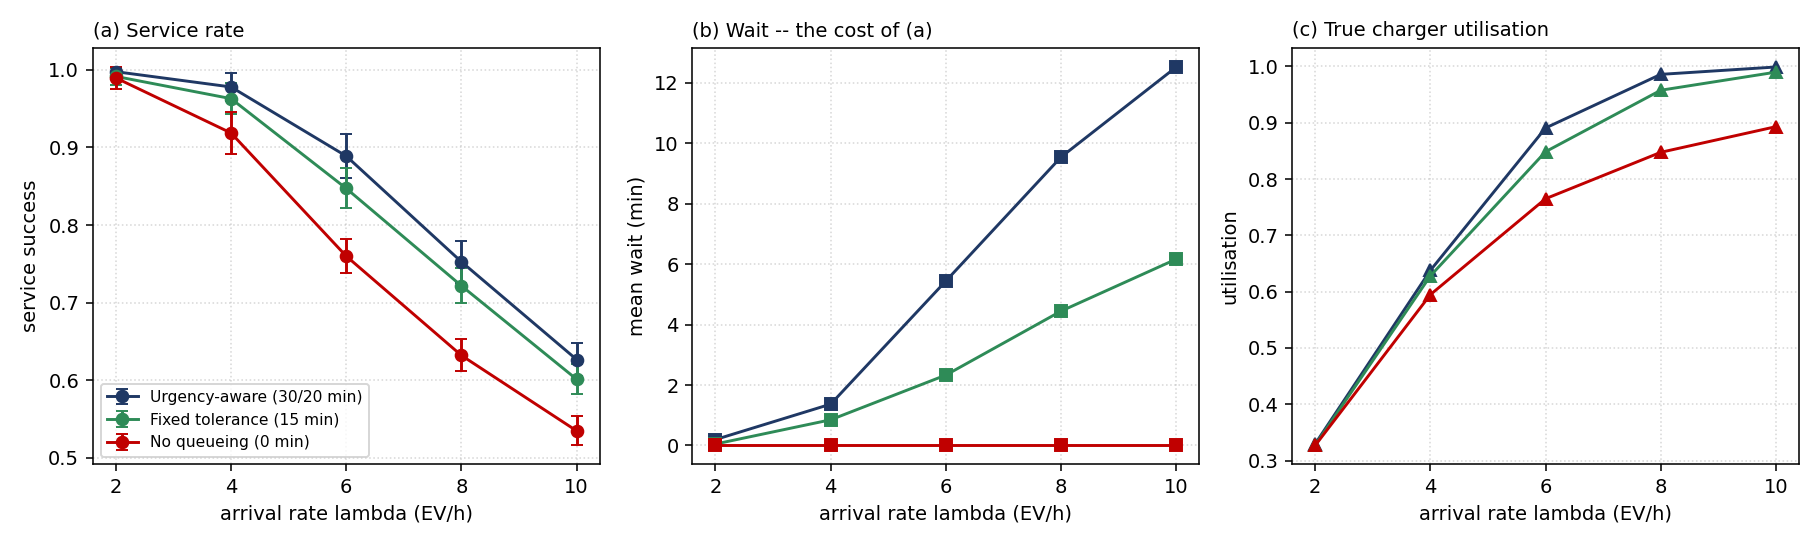

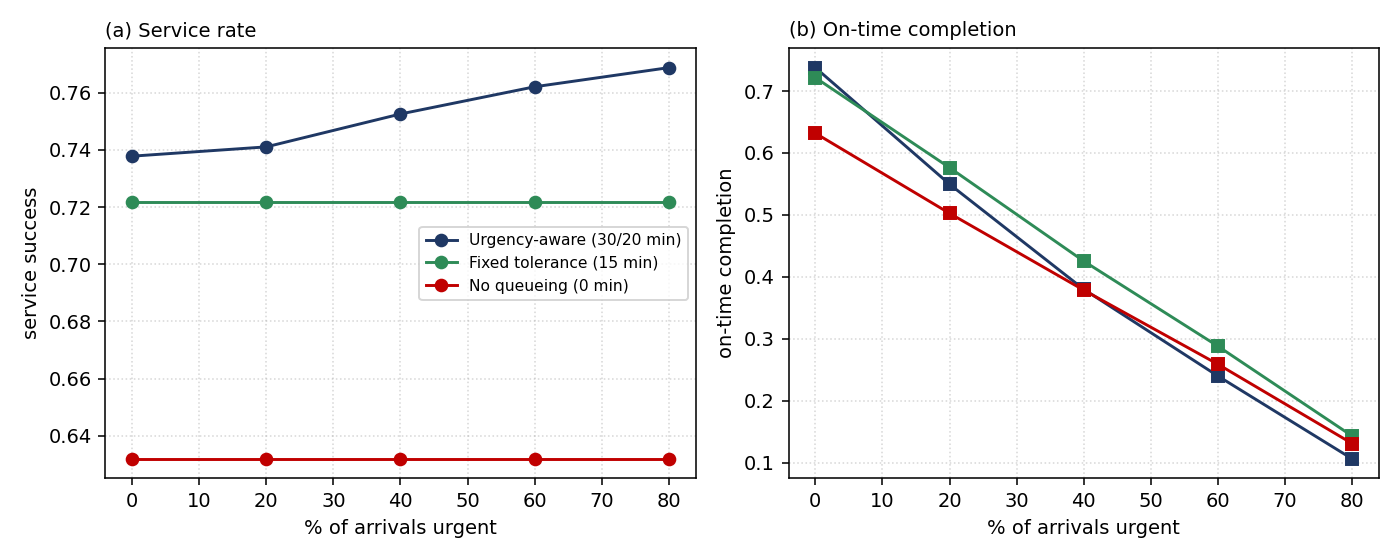

In [7]:
"""
Q-EVCS+ v2 -- MODULE 5: charger allocation (controlled simulation).

Changes vs v1 (review items 4.7, 4.8):
  * v1 compared three arms named "Q-EVCS+", "PPO-style" and "DQN (FIFO)". They
    differ in exactly one respect -- how long a vehicle will wait when all
    chargers are busy (30/20 min, 15 min, 0 min). No policy network, no
    Q-function and no learning appear anywhere in the code. The names implied a
    comparison against trained RL baselines that does not exist, and the ordering
    they produce is tautological: more patience admits more vehicles.
    The arms are now named by their patience parameter and the experiment is
    framed as a queue-tolerance sensitivity analysis on an M/G/c station.
  * The wait cost is now reported alongside the service gain. v1's Table 11 gave
    success rate only, so the reader could not see that the best-serving arm also
    waits roughly twice as long.
  * v1's "utilisation" was mean(busy > 0), where busy holds each charger's
    busy-until timestamp -- so any charger ever used counted forever. It measured
    "fraction of chargers ever touched", which is why it read 1.0 almost
    everywhere. Replaced with true utilisation: served time / (c * horizon).
  * v1's Figure 16 radar chart is deleted. It plotted revenue and load-variance
    for these allocation arms, which have neither; the values came from hardcoded
    0.97x and 0.7x multipliers applied to the pricing module's numbers.
  * Confidence intervals across seeds are now reported.
"""
import json, numpy as np, matplotlib
import matplotlib.pyplot as plt

RES = {}
C_CHARGERS = 6
HORIZON = 480  # minutes

# Each arm is a queue-tolerance rule: how many minutes a driver will wait for the
# next free charger. "urgent" drivers are given a longer tolerance in ARM_A only.
ARMS = {
    "urgency_aware_30_20": dict(pat_urgent=30, pat_normal=20,
                                label="Urgency-aware (30/20 min)"),
    "fixed_15":            dict(pat_urgent=15, pat_normal=15,
                                label="Fixed tolerance (15 min)"),
    "no_queueing":         dict(pat_urgent=0,  pat_normal=0,
                                label="No queueing (0 min)"),
}


def simulate(arm, lam, urgent_frac, c=C_CHARGERS, T=HORIZON, seed=0):
    """M/G/c station. Arrivals Poisson(lam/h); service U(30,90) min."""
    cfg = ARMS[arm]
    r = np.random.RandomState(seed)
    t = 0.0
    served = total = ontime = 0
    wait_sum = service_time = 0.0
    busy = np.zeros(c)          # busy-until timestamp per charger
    while True:
        t += r.exponential(60.0 / lam)
        if t >= T:
            break
        total += 1
        svc = r.uniform(30, 90)
        urgent = r.rand() < urgent_frac
        deadline = t + (r.uniform(20, 40) if urgent else r.uniform(120, 240))
        free = np.where(busy <= t)[0]
        if len(free) > 0:
            j = free[0]
            busy[j] = t + svc
            served += 1
            service_time += svc
            if t + svc <= deadline:
                ontime += 1
        else:
            j = int(busy.argmin())
            wait = busy[j] - t
            patience = cfg["pat_urgent"] if urgent else cfg["pat_normal"]
            if wait <= patience:
                busy[j] = busy[j] + svc
                served += 1
                service_time += svc
                wait_sum += wait
                if busy[j] <= deadline:
                    ontime += 1
    return dict(
        success=served / max(total, 1),
        ontime=ontime / max(total, 1),
        wait=wait_sum / max(served, 1),
        util=min(service_time / (c * T), 1.0),   # true utilisation
    )


def run(arm, lam, uf, seeds=24):
    runs = [simulate(arm, lam, uf, seed=s) for s in range(seeds)]
    out = {}
    for k in runs[0]:
        v = np.array([x[k] for x in runs])
        out[k] = float(v.mean())
        out[k + "_ci95"] = float(1.96 * v.std(ddof=1) / np.sqrt(len(v)))
    return out


LAMS = [2, 4, 6, 8, 10]
URGS = [0.0, 0.2, 0.4, 0.6, 0.8]

by_rate = {a: {lam: run(a, lam, 0.4) for lam in LAMS} for a in ARMS}
by_urg = {a: {u: run(a, 8, u) for u in URGS} for a in ARMS}
RES["arms"] = {a: ARMS[a]["label"] for a in ARMS}
RES["by_arrival_rate"] = {a: {str(k): v for k, v in by_rate[a].items()} for a in ARMS}
RES["by_urgency"] = {a: {str(k): v for k, v in by_urg[a].items()} for a in ARMS}

print("[alloc] Service rate AND mean wait, by queue tolerance "
      "(6 chargers, 40% urgent, 24 seeds, +/- 95% CI)")
print(f"{'arm':<28}" + "".join(f"{'l='+str(l):>22}" for l in LAMS))
for a in ARMS:
    row = "".join(f"{by_rate[a][l]['success']*100:>10.1f}% "
                  f"{by_rate[a][l]['wait']:>6.1f}min" for l in LAMS)
    print(f"{ARMS[a]['label']:<28}{row}")

print("\n[alloc] the service gain is bought with wait, at lambda = 10:")
ref = by_rate["no_queueing"][10]["success"]
for a in ARMS:
    d = by_rate[a][10]
    print(f"    {ARMS[a]['label']:<28} success {d['success']*100:5.1f}% "
          f"(+{(d['success']-ref)*100:4.1f} pts vs no queueing)  "
          f"mean wait {d['wait']:5.1f} min  true utilisation {d['util']*100:5.1f}%")

# --- figures: measured quantities only ---------------------------------
COL = {"urgency_aware_30_20": "#1F3864", "fixed_15": "#2E8B57", "no_queueing": "#C00000"}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.9))
for a in ARMS:
    s = np.array([by_rate[a][l]["success"] for l in LAMS])
    e = np.array([by_rate[a][l]["success_ci95"] for l in LAMS])
    ax[0].errorbar(LAMS, s, yerr=e, fmt="o-", capsize=3, label=ARMS[a]["label"], color=COL[a])
    ax[1].plot(LAMS, [by_rate[a][l]["wait"] for l in LAMS], "s-", color=COL[a])
    ax[2].plot(LAMS, [by_rate[a][l]["util"] for l in LAMS], "^-", color=COL[a])
ax[0].set_ylabel("service success"); ax[0].set_title("(a) Service rate", loc="left", fontsize=10)
ax[0].legend(fontsize=8)
ax[1].set_ylabel("mean wait (min)"); ax[1].set_title("(b) Wait -- the cost of (a)", loc="left", fontsize=10)
ax[2].set_ylabel("utilisation"); ax[2].set_title("(c) True charger utilisation", loc="left", fontsize=10)
for a_ in ax:
    a_.set_xlabel("arrival rate lambda (EV/h)"); a_.grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig("figs/fig14_allocation.png", dpi=140); plt.close()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
xu = [int(u * 100) for u in URGS]
for a in ARMS:
    ax[0].plot(xu, [by_urg[a][u]["success"] for u in URGS], "o-", label=ARMS[a]["label"], color=COL[a])
    ax[1].plot(xu, [by_urg[a][u]["ontime"] for u in URGS], "s-", color=COL[a])
ax[0].set_ylabel("service success"); ax[0].set_title("(a) Service rate", loc="left", fontsize=10)
ax[0].legend(fontsize=8)
ax[1].set_ylabel("on-time completion"); ax[1].set_title("(b) On-time completion", loc="left", fontsize=10)
for a_ in ax:
    a_.set_xlabel("% of arrivals urgent"); a_.grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig("figs/fig15_urgency.png", dpi=140); plt.close()

json.dump(RES, open("results_allocation.json", "w"), indent=2, default=float)
print("\n[alloc] allocation module done (v1 Figure 16 radar intentionally not produced)")

from IPython.display import Image, display
display(Image("figs/fig14_allocation.png"))
display(Image("figs/fig15_urgency.png"))


## 7. Baaki data-figures (6, 7, 8, 9, 11, 12) — consolidated metrics se

[figs] regenerated Figures 6, 7, 8, 9, 11, 12 from consolidated metrics


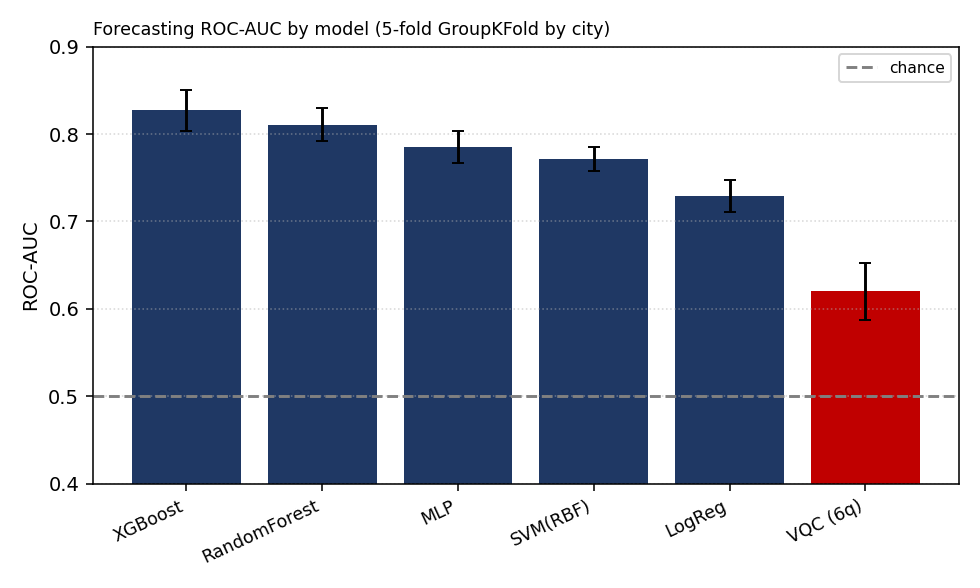

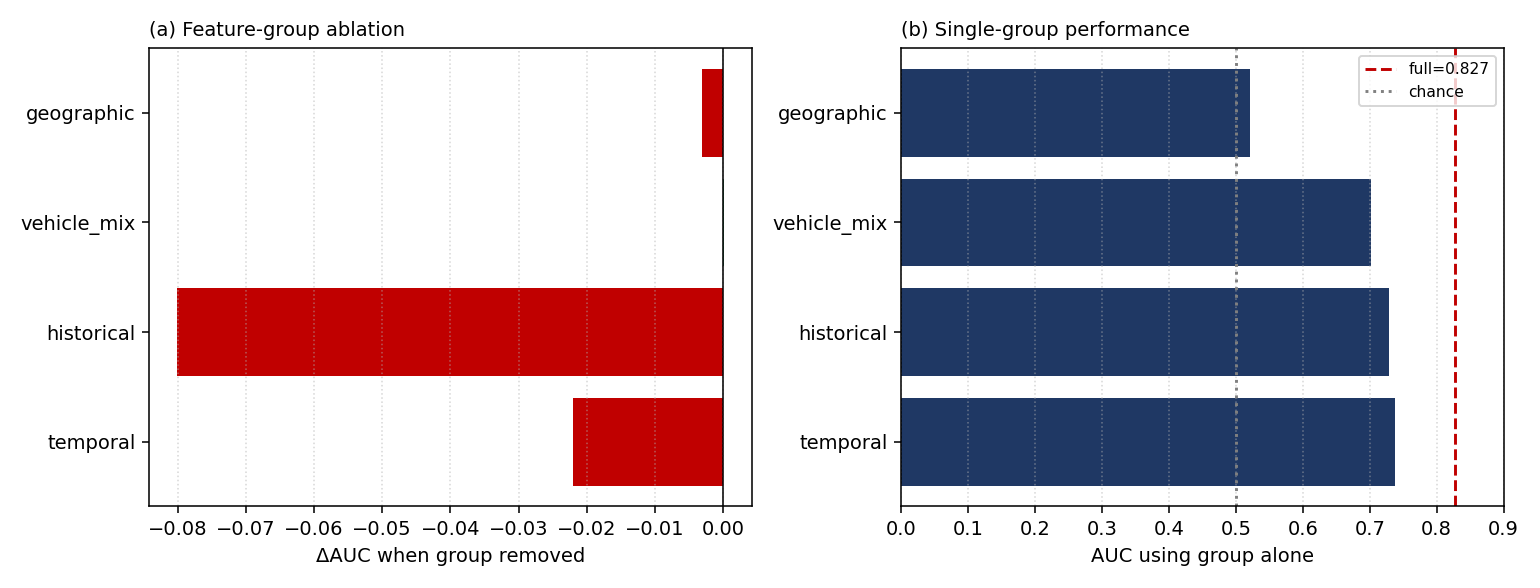

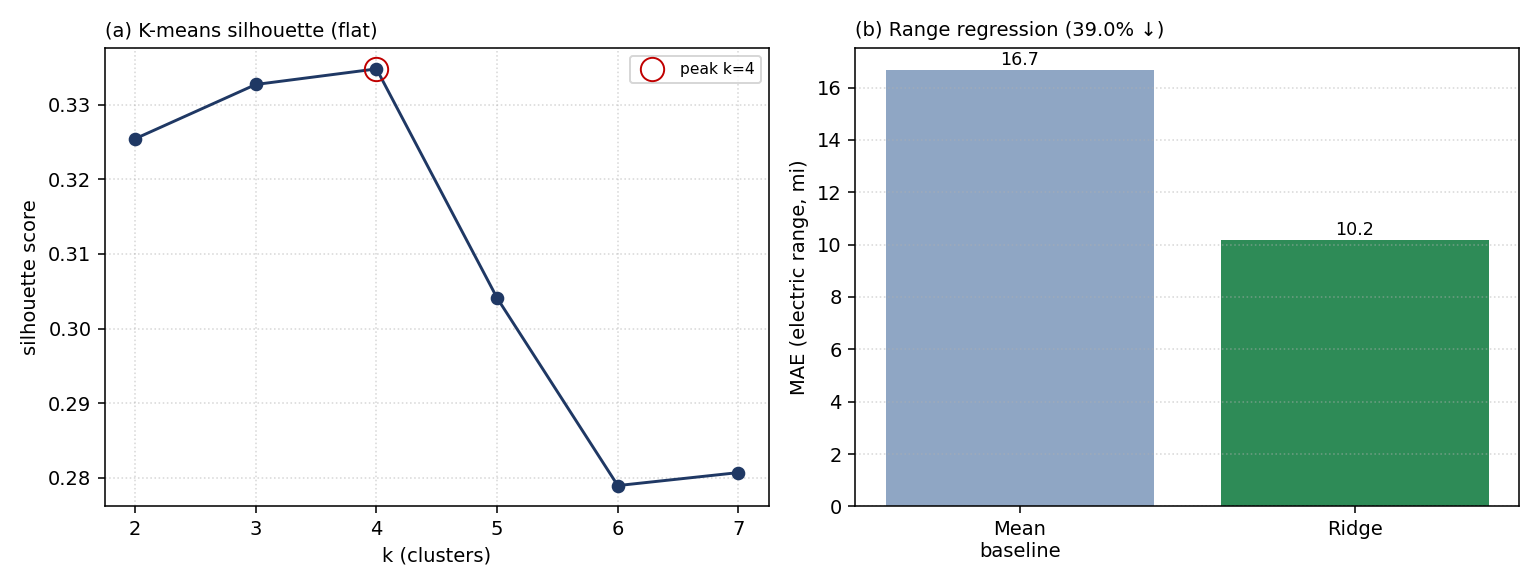

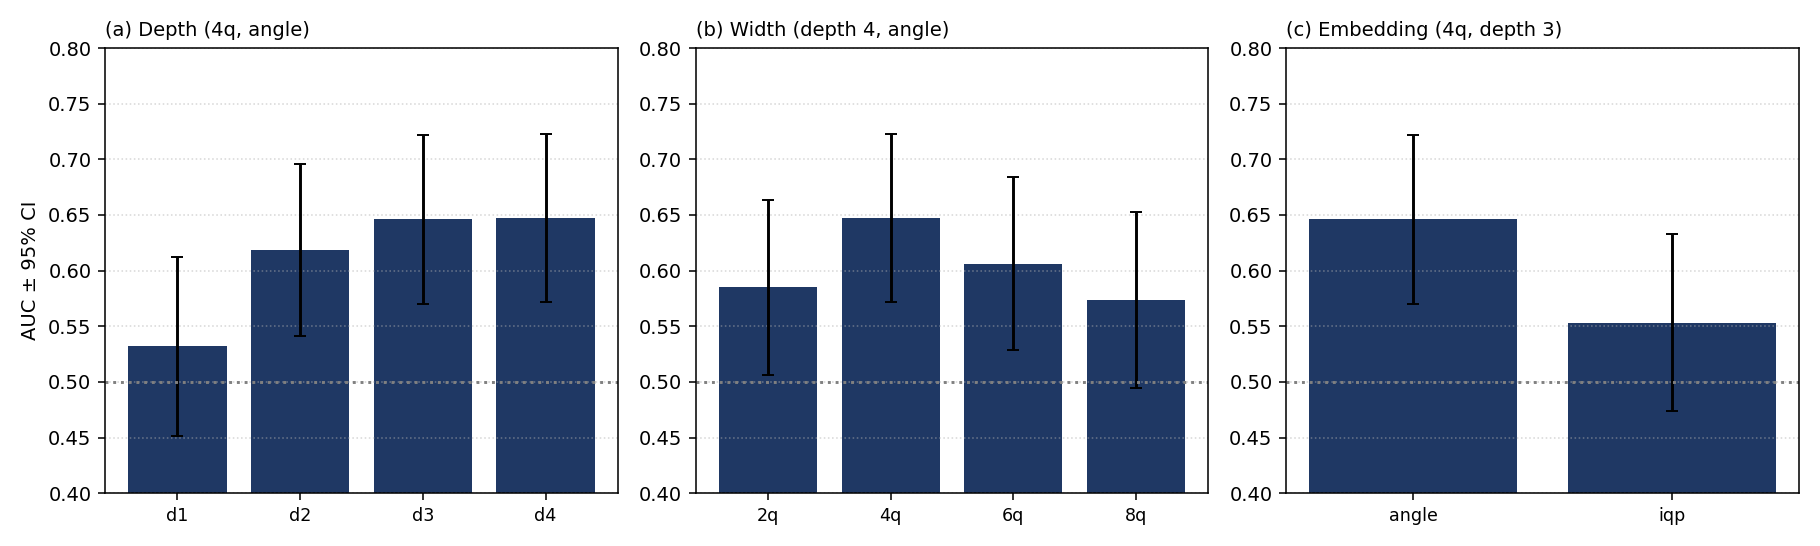

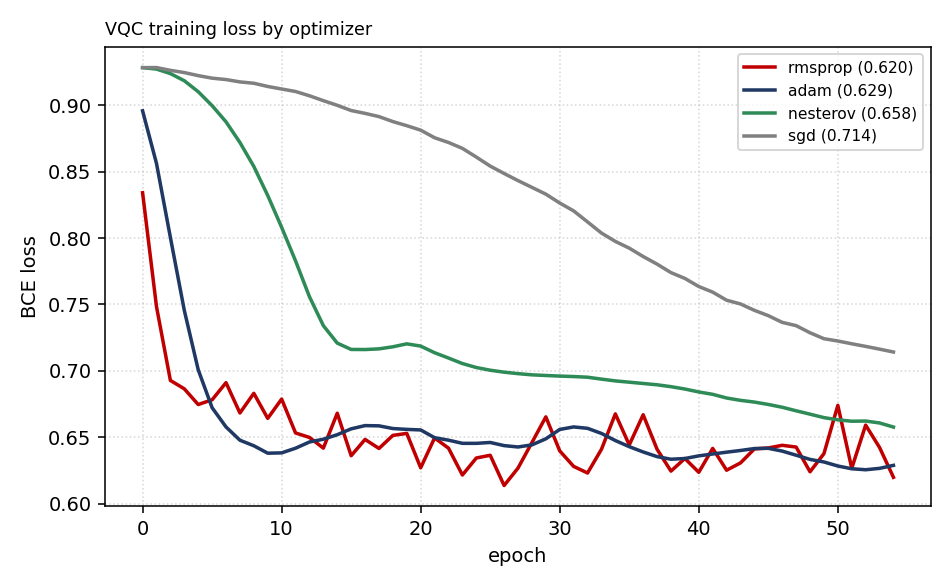

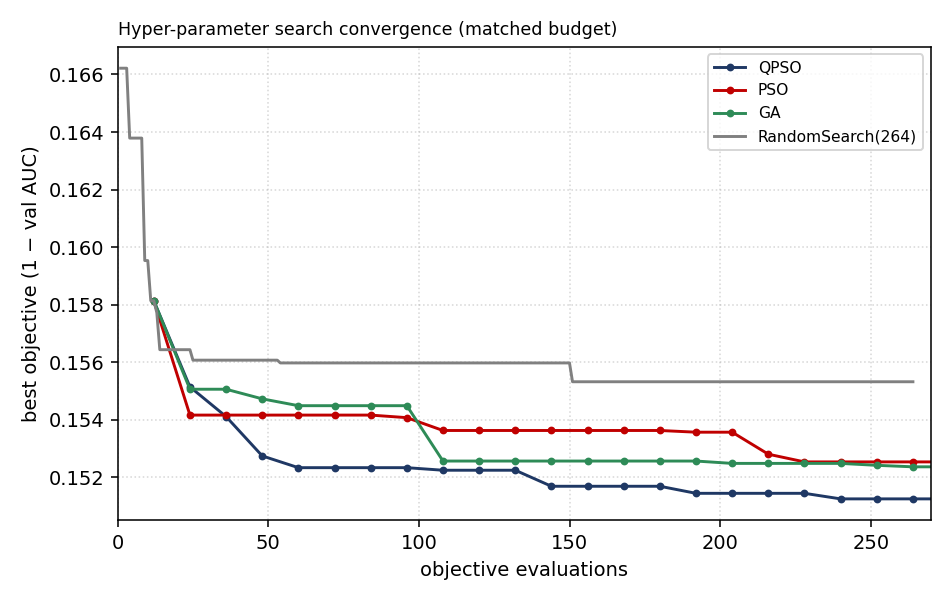

In [8]:
"""Paper figures generated from the consolidated per-module metrics.

Modules 1-5 above emit Figures 10, 13, 13b, 14 and 15 directly. This cell
regenerates the remaining data figures (6, 7, 8, 9, 11, 12) from the same
results_*.json files, so that every data figure in the manuscript is produced
by this notebook rather than by any external process -- the reproducibility
claim of the Integrity Statement (Section 8) then holds for all of them.
"""
import json, numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import os
os.makedirs("figs", exist_ok=True)

core = json.load(open("results_core.json"))
q    = json.load(open("results_quantum.json"))
opt  = json.load(open("results_opt.json"))

NAVY, RED, GREEN, GREY, STEEL = "#1F3864", "#C00000", "#2E8B57", "#808080", "#8FA6C4"
DPI = 140


def _save(f, name):
    f.tight_layout(); f.savefig(name, dpi=DPI); plt.close(f)


# --- Figure 6: forecasting ROC-AUC by model (classical baselines + VQC) ---
bench = core["benchmark"]; order = ["XGBoost", "RandomForest", "MLP", "SVM(RBF)", "LogReg"]
vals = [bench[m]["auc"][0] for m in order] + [q["vqc_auc"]]
errs = [bench[m]["auc"][1] for m in order] + [q["vqc_auc_std"]]
labels = order + ["VQC (6q)"]
f, a = plt.subplots(figsize=(7.0, 4.2))
a.bar(range(len(vals)), vals, yerr=errs, capsize=3, color=[NAVY] * 5 + [RED])
a.axhline(0.5, ls="--", c=GREY, label="chance")
a.set_xticks(range(len(labels))); a.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
a.set_ylabel("ROC-AUC"); a.set_ylim(0.4, 0.9)
a.set_title("Forecasting ROC-AUC by model (5-fold GroupKFold by city)", fontsize=9, loc="left")
a.legend(fontsize=8); a.grid(axis="y", ls=":", alpha=0.5)
_save(f, "figs/fig6_models.png")

# --- Figure 7: feature-group ablation ---
fams = ["temporal", "historical", "vehicle_mix", "geographic"]
solo = [core["ablation_only"][x] for x in fams]
removed = [core["ablation_remove"][x] for x in fams]   # positive = drop when removed
full = core["ablation_full_auc"]
f, ax = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax[0].barh(fams, [-r for r in removed], color=[RED if r > 0 else GREEN for r in removed])
ax[0].axvline(0, c="k", lw=0.8); ax[0].set_xlabel("ΔAUC when group removed")
ax[0].set_title("(a) Feature-group ablation", fontsize=10, loc="left")
ax[0].grid(axis="x", ls=":", alpha=0.5)
ax[1].barh(fams, solo, color=NAVY)
ax[1].axvline(full, ls="--", c=RED, label=f"full={full:.3f}")
ax[1].axvline(0.5, ls=":", c=GREY, label="chance")
ax[1].set_xlabel("AUC using group alone"); ax[1].set_xlim(0, 0.9)
ax[1].set_title("(b) Single-group performance", fontsize=10, loc="left")
ax[1].legend(fontsize=8); ax[1].grid(axis="x", ls=":", alpha=0.5)
_save(f, "figs/fig7_ablation.png")

# --- Figure 8: silhouette curve + range regression ---
sil = core["silhouette"]; ks = sorted(int(k) for k in sil); sv = [sil[str(k)] for k in ks]
bestk = core["best_k"]
f, ax = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax[0].plot(ks, sv, "o-", color=NAVY)
ax[0].plot(bestk, sil[str(bestk)], "o", ms=12, mfc="none", mec=RED, label=f"peak k={bestk}")
ax[0].set_xlabel("k (clusters)"); ax[0].set_ylabel("silhouette score")
ax[0].set_title("(a) K-means silhouette (flat)", fontsize=10, loc="left")
ax[0].legend(fontsize=8); ax[0].grid(ls=":", alpha=0.5)
mb, mr, imp = core["baseline_mae"], core["ridge_mae"], core["ridge_improve_pct"]
ax[1].bar(["Mean\nbaseline", "Ridge"], [mb, mr], color=[STEEL, GREEN])
ax[1].set_ylabel("MAE (electric range, mi)")
ax[1].set_title(f"(b) Range regression ({imp:.1f}% ↓)", fontsize=10, loc="left")
for i, v in enumerate([mb, mr]):
    ax[1].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=9)
ax[1].grid(axis="y", ls=":", alpha=0.5)
_save(f, "figs/fig8_cluster_range.png")

# --- Figure 9: VQC architecture sweeps (with 95% CIs) ---
sw = q["arch_sweeps"]
f, ax = plt.subplots(1, 3, figsize=(13.0, 3.9))
def _block(a, name, keys, labs):
    r = sw[name]["results"]
    v = [r[k]["auc"] for k in keys]; e = [r[k]["ci95"] for k in keys]
    a.bar(range(len(v)), v, yerr=e, capsize=3, color=NAVY); a.axhline(0.5, ls=":", c=GREY)
    a.set_xticks(range(len(labs))); a.set_xticklabels(labs, fontsize=9)
    a.set_ylim(0.4, 0.8); a.grid(axis="y", ls=":", alpha=0.5)
_block(ax[0], "depth", ["1", "2", "3", "4"], ["d1", "d2", "d3", "d4"])
ax[0].set_title("(a) Depth (4q, angle)", fontsize=10, loc="left"); ax[0].set_ylabel("AUC ± 95% CI")
_block(ax[1], "width", ["2", "4", "6", "8"], ["2q", "4q", "6q", "8q"])
ax[1].set_title("(b) Width (depth 4, angle)", fontsize=10, loc="left")
_block(ax[2], "embedding", ["angle", "iqp"], ["angle", "iqp"])
ax[2].set_title("(c) Embedding (4q, depth 3)", fontsize=10, loc="left")
_save(f, "figs/fig9_vqc_arch.png")

# --- Figure 11: VQC optimizer training-loss trajectories ---
oh, fl = q["opt_hist"], q["opt_final_loss"]
f, a = plt.subplots(figsize=(6.8, 4.2))
colmap = {"rmsprop": RED, "adam": NAVY, "nesterov": GREEN, "sgd": GREY}
for name in ["rmsprop", "adam", "nesterov", "sgd"]:
    a.plot(oh[name], color=colmap[name], lw=1.8, label=f"{name} ({fl[name]:.3f})")
a.set_xlabel("epoch"); a.set_ylabel("BCE loss")
a.set_title("VQC training loss by optimizer", fontsize=9, loc="left")
a.legend(fontsize=8); a.grid(ls=":", alpha=0.5)
_save(f, "figs/fig11_optimizers.png")

# --- Figure 12: metaheuristic convergence vs evaluations (matched budget) ---
hist = opt["hist"]; POP = 12
f, a = plt.subplots(figsize=(6.8, 4.3))
cm = {"QPSO": NAVY, "PSO": RED, "GA": GREEN, "RandomSearch(264)": GREY}
for name in ["QPSO", "PSO", "GA"]:
    h = hist[name]; xs = [POP * (k + 1) for k in range(len(h))]
    a.plot(xs, [1 - x for x in h], "o-", ms=3, color=cm[name], label=name)
h = hist["RandomSearch(264)"]
a.plot(range(1, len(h) + 1), [1 - x for x in h], "-", lw=1.5,
       color=cm["RandomSearch(264)"], label="RandomSearch(264)")
a.set_xlabel("objective evaluations"); a.set_ylabel("best objective (1 − val AUC)")
a.set_title("Hyper-parameter search convergence (matched budget)", fontsize=9, loc="left")
a.legend(fontsize=8); a.grid(ls=":", alpha=0.5); a.set_xlim(0, 270)
_save(f, "figs/fig12_convergence.png")

print("[figs] regenerated Figures 6, 7, 8, 9, 11, 12 from consolidated metrics")

from IPython.display import Image, display
display(Image("figs/fig6_models.png"))
display(Image("figs/fig7_ablation.png"))
display(Image("figs/fig8_cluster_range.png"))
display(Image("figs/fig9_vqc_arch.png"))
display(Image("figs/fig11_optimizers.png"))
display(Image("figs/fig12_convergence.png"))


## 8. Saari TABLES (2, 4, 5, 6, 7, 8, 9, 10, 11)

In [9]:
import os

# ============================================================
#  Saari TABLES ko DataFrame ki tarah render karo
# ============================================================
import json, pandas as pd, numpy as np
pd.set_option("display.max_columns", None); pd.set_option("display.width", 160)

def load(f):
    try: return json.load(open(f))
    except FileNotFoundError: print("missing:", f); return {}

core = load("results_core.json"); q = load("results_quantum.json")
opt  = load("results_opt.json");  rl = load("results_rl_pricing.json")
al   = load("results_allocation.json")

def showtab(title, df):
    print("\n" + "="*70 + f"\n{title}\n" + "="*70)
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))

# ---- Table 2: dataset summary (full-census valid range basis) ----
if core:
    import pandas as _pd
    df_csv = _pd.read_csv(os.environ["EV_CSV"])
    rv = df_csv["Electric Range"].where(df_csv["Electric Range"] > 0).dropna()
    t2 = pd.DataFrame({
        "Property": ["Total vehicles","Battery-electric (BEV)","Plug-in hybrid (PHEV)",
                     "Model-year span","Washington counties","Distinct manufacturers",
                     "Mean / median range (valid)","Feature columns"],
        "Value": [f"{core['dataset_rows']:,}",
                  f"{core['n_bev']:,} ({100*core['n_bev']/core['dataset_rows']:.1f}%)",
                  f"{core['n_phev']:,} ({100*core['n_phev']/core['dataset_rows']:.1f}%)",
                  f"{core['year_min']}–{core['year_max']}",
                  f"{core.get('n_wa_counties','?')}",
                  f"{core['n_makes']}",
                  f"{rv.mean():.2f} / {rv.median():.2f} mi",
                  f"{core['ml_features']}"]})
    showtab("Table 2 — Dataset summary", t2)

# ---- Table 4: forecasting benchmark ----
if core.get("benchmark"):
    rows=[]
    for m,v in core["benchmark"].items():
        rows.append([m, f"{v['auc'][0]:.3f} ± {v['auc'][1]:.3f}",
                     f"{v['acc'][0]:.3f}", f"{v['prec'][0]:.3f}",
                     f"{v['rec'][0]:.3f}", f"{v['f1'][0]:.3f}"])
    showtab("Table 4 — Forecasting benchmark (5-fold GroupKFold by city)",
            pd.DataFrame(rows, columns=["Model","ROC-AUC","Acc","Prec","Rec","F1"]))

# ---- Table 5: ablation ----
if core.get("ablation_only"):
    rows=[]
    for fam in ["temporal","historical","vehicle_mix","geographic"]:
        rows.append([fam.capitalize(), f"{core['ablation_only'][fam]:.3f}",
                     f"{-core['ablation_remove'][fam]*100:+.1f}"])
    showtab(f"Table 5 — Feature-group ablation (full-model AUC = {core['ablation_full_auc']:.3f}); ΔAUC in points ×100",
            pd.DataFrame(rows, columns=["Feature family","AUC (only)","ΔAUC (removed)"]))

# ---- Table 6: city clusters ----
if core.get("cluster_stats"):
    cs = core["cluster_stats"]; ks = sorted(cs["n_cities"], key=lambda x:int(x))
    rows=[]
    for k in ks:
        n=int(cs["n_cities"][k]); lbl=f"C{k}"+(" (singleton)" if n==1 else f" ({n})")
        rows.append([lbl, f"{cs['mean_vehicles'][k]:,.0f}",
                     f"{cs['bev_share'][k]*100:.1f}%", f"{cs['avg_range'][k]:.1f} mi"])
    showtab(f"Table 6 — City-cluster archetypes at k={core['best_k']}",
            pd.DataFrame(rows, columns=["Cluster (cities)","Mean vehicles","BEV share","Avg. range"]))

# ---- Table 7: VQC sweeps ----
if q.get("arch_sweeps"):
    rows=[]
    lab={"depth":"Depth","width":"Width","embedding":"Embed"}
    for name,blk in q["arch_sweeps"].items():
        held=", ".join(f"{k}={v}" for k,v in blk["held_constant"].items())
        for cfg,r in blk["results"].items():
            rows.append([f"{lab[name]} {cfg}", f"{r['auc']:.3f} ± {r['ci95']:.3f}", held])
    showtab("Table 7 — VQC architecture sweeps (AUC ± 95% CI)",
            pd.DataFrame(rows, columns=["Configuration","AUC ± 95% CI","held constant"]))

# ---- Table 8: barren variances ----
if q.get("barren_var"):
    rows=[[f"{k} qubits", f"{v:.2e}"] for k,v in q["barren_var"].items()]
    showtab(f"Table 8 — Gradient-variance decay (log-slope {q['barren_log_slope']:.3f} "
            f"[{q['barren_log_slope_ci95'][0]:.3f}, {q['barren_log_slope_ci95'][1]:.3f}])",
            pd.DataFrame(rows, columns=["Register width","Var[∂L/∂θ]"]))

# ---- Table 9: optimiser ----
if opt.get("results"):
    rows=[]
    for m,v in opt["results"].items():
        rows.append([m, f"{v['mean_auc']:.4f} ± {v['std_auc']:.4f}",
                     f"{v['mean_time_s']:.0f}s", f"{v['mean_unique_evals']:.0f}"])
    showtab("Table 9 — Hyper-parameter search (5 seeds, matched budget 264)",
            pd.DataFrame(rows, columns=["Search strategy","Val. AUC (mean ± std)","Time","Unique evals"]))

# ---- Table 10: pricing ----
if rl:
    rows=[["Operator revenue", f"{rl['rev_gain_vs_tou']:+.1f}%"],
          ["Peak load variance", f"{-rl['var_reduction_vs_tou']:+.1f}% (i.e. {rl['var_reduction_vs_tou']:.1f}% reduction)"],
          ["Price–solar correlation", f"{rl['price_solar_corr']:.3f}"],
          ["Avg. tariff (REINFORCE / ToU)", f"${rl['ucost_agent']:.3f} / ${rl['ucost_tou']:.3f} per kWh"],
          ["Revenue vs. RTP", f"{rl['rev_gain_vs_rtp']:+.1f}%"]]
    showtab(f"Table 10 — Learned dynamic-pricing outcomes (REINFORCE, η={rl['eta_headline']})",
            pd.DataFrame(rows, columns=["Metric (vs. flat ToU)","Result"]))

# ---- Table 11: allocation ----
if al.get("by_arrival_rate"):
    arms=list(al["arms"]); lams=["2","4","6","8","10"]
    labels={a:al["arms"][a] for a in arms}
    ua=[a for a in arms if "urgency" in a][0]
    rows=[]
    for lam in lams:
        row=[f"λ = {lam}"]
        for a in arms:
            row.append(f"{al['by_arrival_rate'][a][lam]['success']*100:.1f}%")
        row.append(f"{al['by_arrival_rate'][ua][lam]['wait']:.1f}")
        rows.append(row)
    cols=["Arrival rate"]+[labels[a] for a in arms]+["Mean wait, urgency-aware (min)"]
    showtab("Table 11 — Service success & mean wait vs arrival rate (6 chargers, 40% urgent)",
            pd.DataFrame(rows, columns=cols))

# ---- consolidate ----
allr={}
for d in [core,q,opt,rl,al]: allr.update(d)
json.dump(allr, open("results_all_v2.json","w"), indent=2, default=float)
print("\n✅ results_all_v2.json saved. Saari figs/ aur results_*.json is folder mein maujood hain.")



Table 2 — Dataset summary


,Property,Value
0,Total vehicles,"177,866"
1,Battery-electric (BEV),"139,210 (78.3%)"
2,Plug-in hybrid (PHEV),"38,656 (21.7%)"
3,Model-year span,1997–2024
4,Washington counties,39
5,Distinct manufacturers,40
6,Mean / median range (valid),121.82 / 84.00 mi
7,Feature columns,11



Table 4 — Forecasting benchmark (5-fold GroupKFold by city)


,Model,ROC-AUC,Acc,Prec,Rec,F1
0,XGBoost,0.827 ± 0.023,0.740,0.737,0.739,0.738
1,RandomForest,0.811 ± 0.019,0.731,0.733,0.722,0.728
2,MLP,0.785 ± 0.019,0.709,0.713,0.693,0.702
3,SVM(RBF),0.771 ± 0.014,0.701,0.699,0.698,0.698
4,LogReg,0.729 ± 0.019,0.654,0.645,0.676,0.660



Table 5 — Feature-group ablation (full-model AUC = 0.827); ΔAUC in points ×100


...


Table 10 — Learned dynamic-pricing outcomes (REINFORCE, η=-0.6)


,Metric (vs. flat ToU),Result
0,Operator revenue,+32.0%
1,Peak load variance,-30.7% (i.e. 30.7% reduction)
2,Price–solar correlation,-0.950
3,Avg. tariff (REINFORCE / ToU),$0.425 / $0.223 per kWh
4,Revenue vs. RTP,+1.3%



Table 11 — Service success & mean wait vs arrival rate (6 chargers, 40% urgent)


,Arrival rate,Urgency-aware (30/20 min),Fixed tolerance (15 min),No queueing (0 min),"Mean wait, urgency-aware (min)"
0,λ = 2,99.8%,99.2%,99.0%,0.2
1,λ = 4,97.8%,96.3%,91.9%,1.4
2,λ = 6,88.9%,84.7%,76.0%,5.4
3,λ = 8,75.3%,72.2%,63.2%,9.5
4,λ = 10,62.7%,60.1%,53.5%,12.5



✅ results_all_v2.json saved. Saari figs/ aur results_*.json is folder mein maujood hain.


## 9. (Optional) files download karo

In [10]:
from google.colab import files
for f in ["results_all_v2.json","results_core.json","results_quantum.json",
          "results_opt.json","results_rl_pricing.json","results_allocation.json"]:
    try: files.download(f)
    except Exception as e: print("skip", f, e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>